# Introducción
### **Descripción del problema**
La obesidad es reconocida en Argentina como un importante problema de salud pública. Existen campañas y programas, tanto a nivel nacional como provincial, que buscan reducir su prevalencia. Sin embargo, según datos de la Encuesta Nacional de Factores de Riesgo (ENFR), la tendencia sigue en aumento: en 2018, 6 de cada 10 personas presentaban exceso de peso, y 2 de esas 6 tenían obesidad.
Frente a este panorama, este proyecto propone mirar el problema desde otra perspectiva: ¿qué se dice sobre la obesidad en las redes sociales? ¿Cómo se construye el discurso público sobre el tema? Se parte de la idea de que factores culturales y sociales también pueden influir en este fenómeno y que, al analizarlos, podríamos entender mejor por qué sigue creciendo.
Para esto, trabajamos con un conjunto de datos compuesto por tweets que mencionan palabras clave relacionadas con la obesidad. Esta base incluye información como el contenido del tweet, la cantidad de likes, retweets, respuestas, citas, la fecha de publicación, el mes y la provincia desde donde fue publicado. A partir de este material, el proyecto busca explorar cómo se percibe y discute la obesidad en el espacio digital, qué temas predominan, qué emociones circulan y si existen diferencias regionales o temporales en la forma en que se habla del tema.

A partir de este dataset, se busca conocer un poco más sobre la percepción social de la obesidad, a partir de tópicos de discusión, patrones de interacción (likes, retweets, respuestas, etc) o análisis de sentimiento. Además, se pueden explorar posibles diferencias regionales o estacionales en los tweets y su relación con características propias del lenguaje. El proyecto también deja abierta la posibilidad de explorar otros aspectos relacionados con la temática y los distintos enfoques sobre la obesidad.


### **Problemas interesantes a abordar**

¿Cuáles son los principales temas de conversación sobre obesidad en Twitter?
¿Existen diferencias en el contenido compartido según la provincia? ¿Y según el mes?
¿Cómo varía el nivel de interacción (likes, retweets, respuestas) según el tipo de contenido del tweet?
¿Se pueden detectar períodos de mayor actividad relacionados con eventos específicos?
¿La cantidad de palabras que se utilizan en el tweet se asocia a un sentimiento negativo o positivo, o es indistinto?

### **Descripción del dataset**
Este repositorio contiene una base de datos con 11111 registros y 13 columnas recopilados de Twitter a partir de palabras clave sobre obesidad. La información fue extraída con el objetivo de analizar conversaciones en torno a la obesidad en Argentina, incluyendo interacciones, fechas, hashtags y datos geográficos. Para identificar la provincia de origen de los usuarios que generaron los tweets, se realizó un proceso de reconocimiento de localidades, ciudades y departamentos más relevantes y frecuentes a partir de la variable "location" asociada a cada usuario. Posteriormente, se asignó una provincia a cada tweet con base en esa información. En los casos en que un tweet presenta dos o más provincias identificadas, esto se debe a que el usuario mencionó múltiples lugares en su descripción de ubicación. Esta variable se denominó "pcia".

Más información disponible [aquí](https://github.com/eugehaluszka/mentoria_2025/tree/main/datasets).

## **Práctico 1**

En esta primera etapa, se trabajará con el dataset de tweets sobre obesidad para realizar un análisis exploratorio inicial. El objetivo es identificar patrones generales en los datos mediante visualizaciones: distribución de tweets por provincia o mes, volumen de interacciones (likes, retweets, respuestas), y posibles tendencias en la conversación pública. También se podrán contemplar la cantidad de palabras utilizadas en cada tweet, así como los términos más utilizados entre otros análisis descriptivos.
Se espera que este práctico permita conocer mejor la estructura de los datos y generar preguntas o hipótesis para análisis posteriores.

### **Cargando el dataset**

In [1]:
#Importar librerias de interes

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import zipfile
%matplotlib inline

In [2]:
#Descargar la base desde el github

!wget -O base_obesidad_completa.zip "https://github.com/eugehaluszka/mentoria_2025/raw/refs/heads/main/datasets/base_obesidad_completa.zip"
with zipfile.ZipFile("base_obesidad_completa.zip", "r") as z:
    z.extractall()

--2025-06-28 00:29:30--  https://github.com/eugehaluszka/mentoria_2025/raw/refs/heads/main/datasets/base_obesidad_completa.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/eugehaluszka/mentoria_2025/refs/heads/main/datasets/base_obesidad_completa.zip [following]
--2025-06-28 00:29:30--  https://raw.githubusercontent.com/eugehaluszka/mentoria_2025/refs/heads/main/datasets/base_obesidad_completa.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1043853 (1019K) [application/zip]
Saving to: ‘base_obesidad_completa.zip’

base_obesidad_compl 100%[===================>]   1019K  --.-KB/s    in 0.04

In [3]:
#Abrir la base de datos
df = pd.read_csv("base_obesidad_completa.csv", encoding="utf-8-sig")
df_original = df.copy() #se genera copia
df.head(5)

,id_str,date,rawContent,replyCount,retweetCount,likeCount,quoteCount,conversationId,hashtags,viewCount,pcia,mes,user_id
0,1747300752475730129,2024-01-16 16:52:17,Boluda ahí dice que yo debería pesar 43kg eso ...,1,0,1.0,0,1747290800474476846,[],18.0,['argentina'],1,0
1,1747297783743197385,2024-01-16 16:40:29,"Jugador de +30 años, vendehumo, con tendencias...",0,0,1.0,0,1747268216882102581,[],21.0,['buenos aires'],1,1
2,1747295025363341318,2024-01-16 16:29:31,"yo, re pesada mal: ✨EL UNIVERSO CONSPIRA A MI ...",0,0,0.0,0,1747295025363341318,[],54.0,['buenos aires'],1,2
3,1747240401788907570,2024-01-16 12:52:28,Me puse una cartera usada que me regalaron y t...,12,11,4074.0,9,1747240401788907570,[],61351.0,[],1,3
4,1747292672232931781,2024-01-16 16:20:10,La tabla de mi pediatra cuando tenia 6 años y ...,0,0,0.0,0,1747292672232931781,[],98.0,['buenos aires'],1,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11111 entries, 0 to 11110
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_str          11111 non-null  int64  
 1   date            11111 non-null  object 
 2   rawContent      11111 non-null  object 
 3   replyCount      11111 non-null  int64  
 4   retweetCount    11111 non-null  int64  
 5   likeCount       11111 non-null  float64
 6   quoteCount      11111 non-null  int64  
 7   conversationId  11111 non-null  int64  
 8   hashtags        11111 non-null  object 
 9   viewCount       11049 non-null  float64
 10  pcia            11111 non-null  object 
 11  mes             11111 non-null  int64  
 12  user_id         11111 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 1.1+ MB


### Conocer el dataset: **Análisis exploratorio**, aplicación de medidas resumen

#### Ejercicio 1.
Cargar dataset y describir brevemente su estructura:
* a. ¿Cuántas filas y columnas tiene?
* b. ¿Qué tipo de variables contiene (texto, numérico, fechas)?
* c. ¿Hay valores faltantes? ¿En qué columnas?
* d. ¿Hay valores atípicos? ¿En qué variables? ¿A qué pueden deberse?

#### Ejercicio 2.
* Elegir 5 columnas y describí su distribución o contenido. Por ejemplo: fecha del tweet (dias, o meses, u horarios), texto del tweet, provincia o ubicación geográfica, cantidad de likes, retweets o respuestas, etc.

*En este ejercicio deberán aplicar conocimientos de estadística sobre medidas resumen adecuadas al tipo de dato contenido en las variables.*


In [5]:
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 11111
Cantidad de columnas: 13


- Variables textuales: `rawContent`, `hashtags`, `pcia`. Tener en cuenta que las dos últimas son listas de strings.
- Variables numéricas (int): `replyCount`, `retweetCount`, `likeCount`, `quoteCount`, `conversationId`, `viewCount`.       
- Variables tipo fecha: `date`. La variable `mes` también podría ser considerada dentro de este grupo pero está codificada como categórica ordinal, con un número del 1 al 12.
- Identificadores únicos: `id_str`, `user_id`, `conversationId`.

In [6]:
# cambiar tipos de  `id_str`, `user_id` a object
df['id_str'] = df['id_str'].astype('object')
df['user_id'] = df['user_id'].astype('object')

df['conversationId'] = df['conversationId'].astype('category')
df['mes'] = df['mes'].astype('category')

<Axes: >

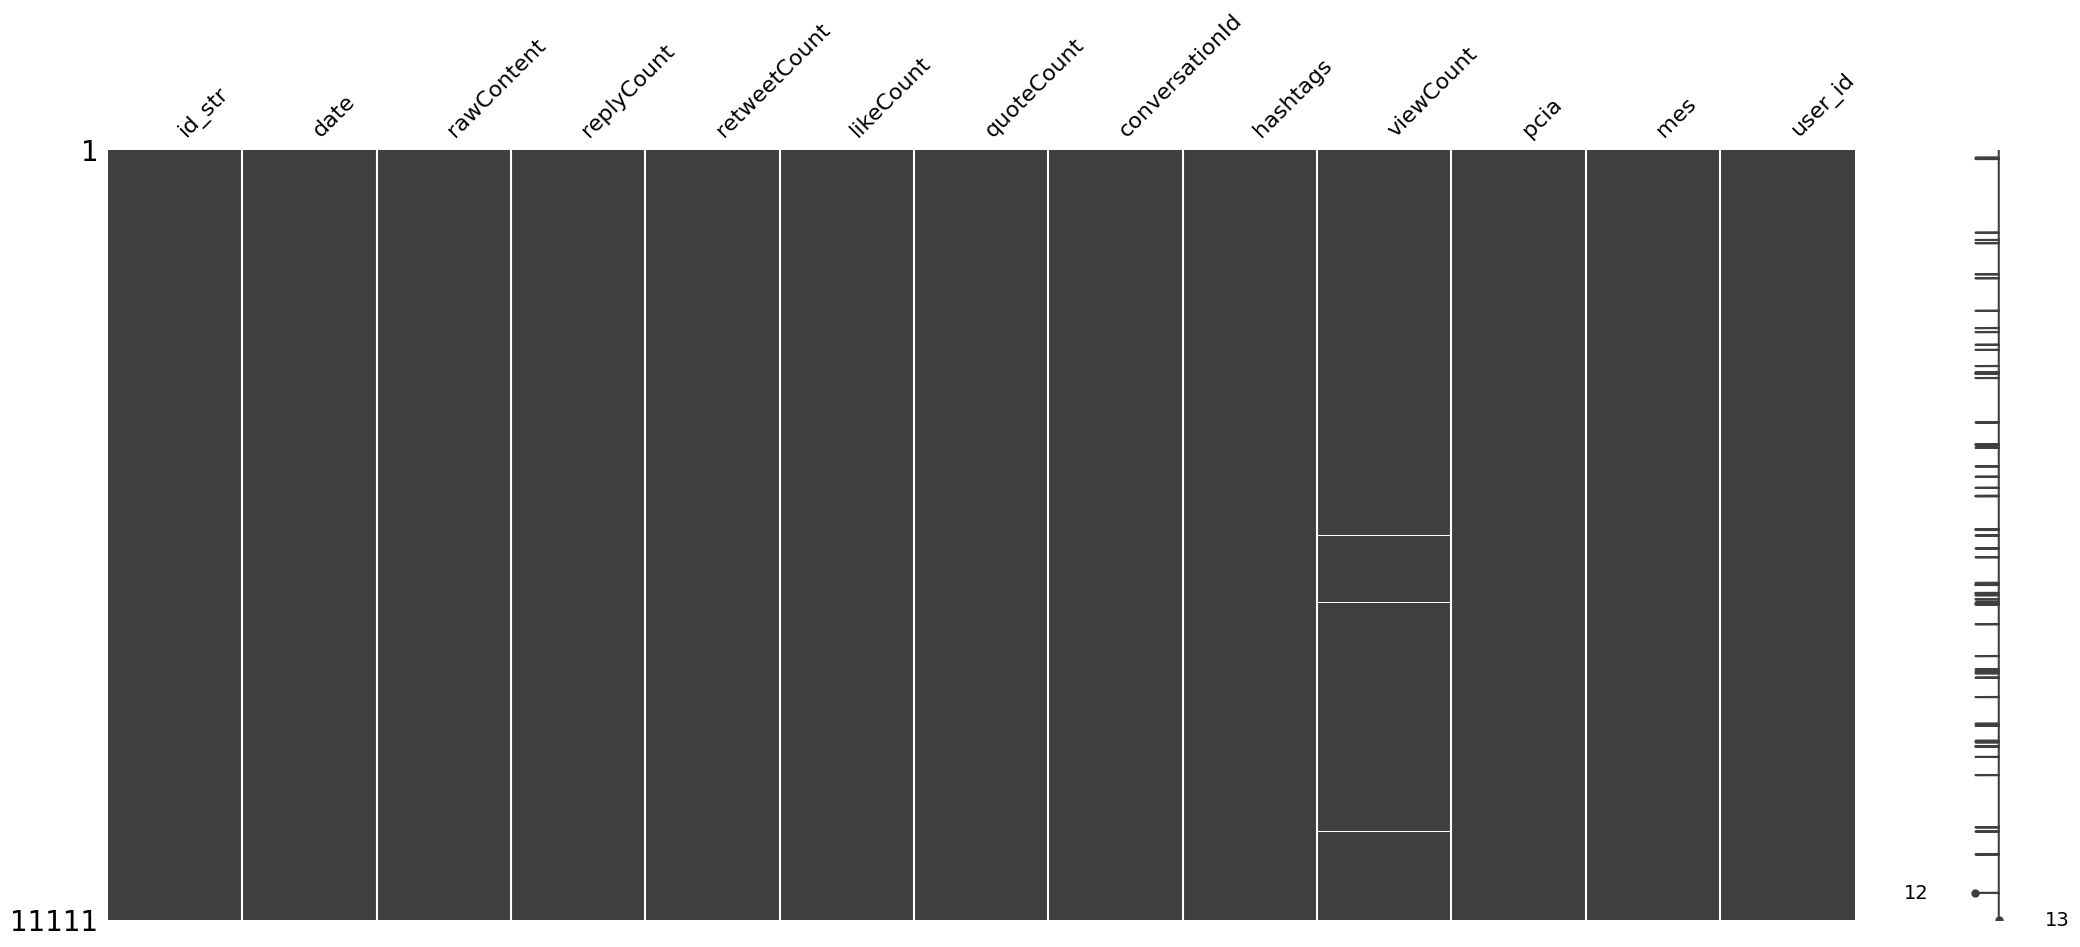

In [7]:
# Generate the missing data matrix
# sería interesante transformar los hashtags vacíos y provincias vacías en NaN para  graficar esto
msno.matrix(df)

Solo la variable `viewCount` tiene algunos datos faltantes, sin embargo, las variables `hashtags` y `pcia` tienen muchas entradas que son listas vacías, es decir, datos faltantes aunque no cuentan como NA.

In [8]:
df.describe()

,replyCount,retweetCount,likeCount,quoteCount,viewCount
count,11111.000000,11111.000000,11111.000000,11111.000000,1.104900e+04
mean,67.335073,168.189092,2097.646386,69.602826,2.556373e+05
std,707.613107,1852.239329,17327.267282,669.779882,2.692944e+06
min,0.000000,0.000000,0.000000,0.000000,1.000000e+00
25%,0.000000,0.000000,0.000000,0.000000,1.700000e+01
50%,0.000000,0.000000,1.000000,0.000000,5.600000e+01
75%,1.000000,0.000000,3.000000,0.000000,2.250000e+02
max,49463.000000,130263.000000,878342.000000,31877.000000,1.544268e+08


In [9]:
df['mes'].mode()

,mes
0,2


In [10]:
df["replyCount"].sort_values(ascending=False).head(20)

,replyCount
10004,49463
8028,20464
2460,16562
857,16436
1661,15225
6853,12456
8217,10972
6583,10898
5772,10753
8515,8907


Las métricas de interacción de las redes sociales suelen tener una distribución de "cola larga" (long-tail) o con un fuerte sesgo a la derecha.La mayoría de los datos se agrupan en valores bajos, pero unos pocos valores atípicos muy altos "estiran" la gráfica; estos valores suelen ser posteos o comentarios virales. Algunas opciones para visualizarlos son:
- Histograma con escala logarítmica. Tener en cuenta que el logaritmo de 0 no está definido, por lo que para graficar se suelen ignorar los ceros o sumar 1 a toda la serie (log(x+1)).
- Filtrar percentiles.


[<Axes: > <Axes: >]


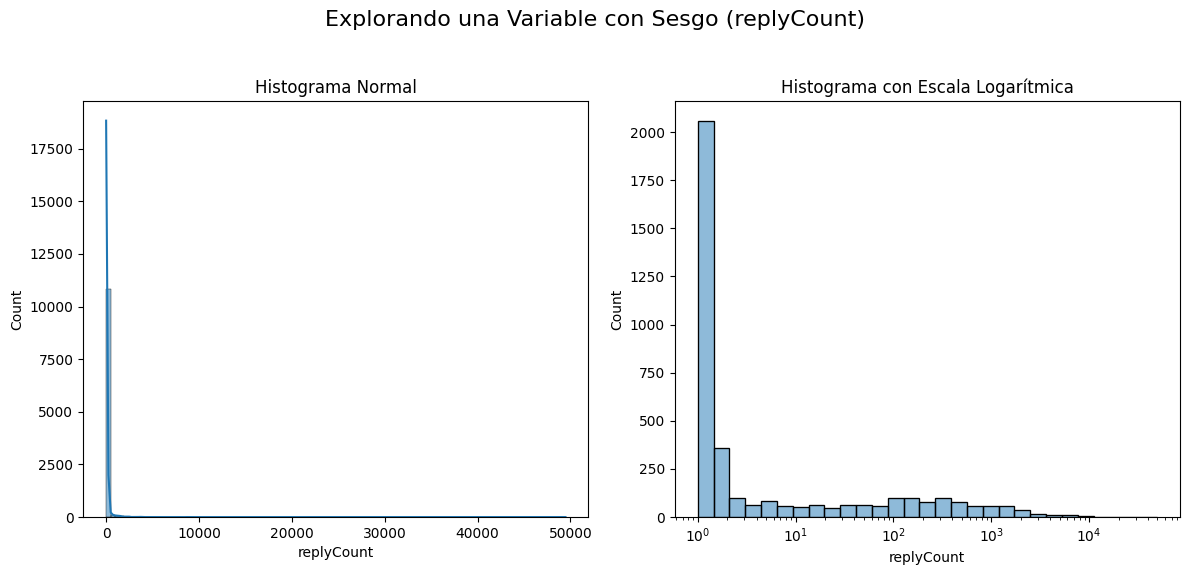

In [11]:
# --- Creación de Gráficos ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
print(axes)
fig.suptitle('Explorando una Variable con Sesgo (replyCount)', fontsize=16)

# 1. Histograma Normal (para comparación)
sns.histplot(df['replyCount'], ax=axes[0], kde=True, bins=100)
axes[0].set_title('Histograma Normal')

# 2. Histograma con Escala Logarítmica
sns.histplot(df['replyCount'], ax=axes[1], kde=True, log_scale=True)
axes[1].set_title('Histograma con Escala Logarítmica')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<Axes: xlabel='replyCount'>

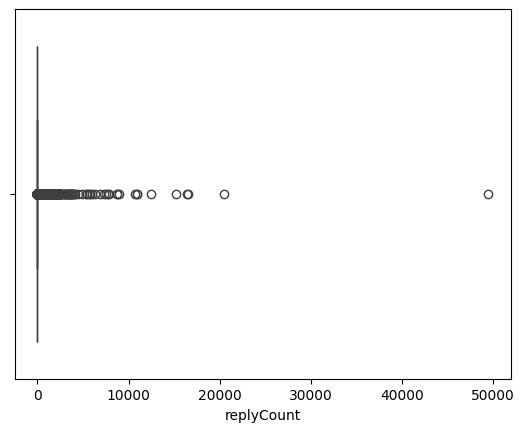

In [12]:
sns.boxplot(x=df['replyCount'])

<Axes: xlabel='replyCount', ylabel='Count'>

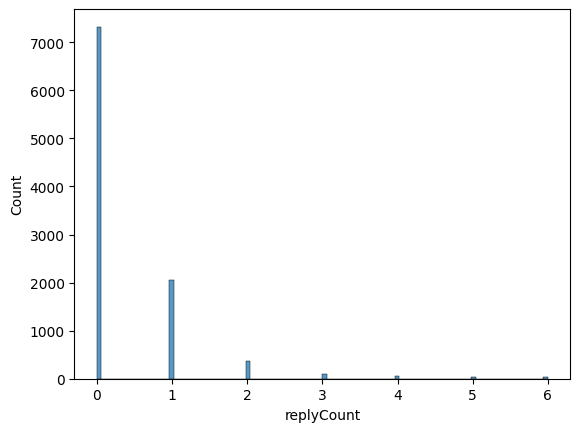

In [13]:
p95 = df['replyCount'].quantile(0.90)
sns.histplot(df[df['replyCount'] < p95]['replyCount'], bins=100)

In [14]:
df["retweetCount"].value_counts().head(20)

,count
retweetCount,
0,9177
1,476
2,129
3,71
4,51
5,40
7,25
6,22
11,15


In [15]:
# Lista de variables que quieres analizar
variables = ['replyCount', 'retweetCount', 'likeCount', 'quoteCount']

# Creo un DataFrame a partir de un diccionario de value_counts
# El índice del nuevo df será la unión de todos los recuentos posibles
summary_df = pd.DataFrame({var: df[var].value_counts() for var in variables})

# Reindexo para tener las filas de 0 a 20
# Relleno con 0 los valores que no existen y convierto a entero
summary_df = summary_df.reindex(range(21)).fillna(0).astype(int)
summary_df


,replyCount,retweetCount,likeCount,quoteCount
0,7323,9177,5440,9727
1,2059,476,2010,258
2,360,129,734,54
3,101,71,404,40
4,65,51,238,23
5,45,40,174,12
6,37,22,128,21
7,26,25,91,8
8,22,12,65,12
9,12,15,64,12


In [16]:
import ast
if type(df['hashtags'].iloc[0]) == str:
    df['hashtags'] = df['hashtags'].apply(ast.literal_eval)
df['hashtags'].explode().value_counts().head(20)

,count
hashtags,
GranHermano,156
Obesidad,50
obesidad,48
granhermano,39
Salud,37
Negocios,23
GranFuria,17
cuestiondepeso,17
Gobierno,16


In [17]:
if type(df['pcia'].iloc[0]) == str:
    df['pcia'] = df['pcia'].apply(ast.literal_eval)
df['pcia'].explode().value_counts().head(20)

,count
pcia,
buenos aires,8400
caba,475
argentina,319
chubut,190
santa fe,131
rio negro,86
tierra del fuego,75
tucuman,59
entre rios,49


### **Visualización de datos**

#### Ejercicio 3
Tendencias de tweets en el tiempo, ¿Qué observamos en nuestro dataset?

* a. Se debe graficar la cantidad de tweets de acuerdo a la fecha (puede ser por mes, día, horario, semana). Al menos dos gráficos.
* b. Interpretar la visualización elegida. ¿Se observan picos o caídas en los gráficos? ¿Qué podría inferir de acuerdo a lo observado?
* c. Respecto a la distribución espacial, se deberá graficar la distribución de tweets por provincia. Elegir una medida adecuada y justificar su elección. (frecuencias absolutas, relativas, quantiles de distribución , etc)
* d. Realizar interpretación del gráfico de distribución espacial. Generar inferencias de acuerdo a lo observado.

#### Ejercicio 4

* a. Retomando el ejercicio 1.d. Cómo podrán observar en la base detectarán que la cantidad de likes, retweets y respuestas suele variar, observandose algunos outliers. ¿Pueden identificarlos? ¿Qué medidas podrían tomar al respecto de acuerdo a la descripción del problema? justificar.
* b. Existen hashtags con mayor o menor frecuencia de uso en esta muestra de datos. ¿Puede reconocerlos? Generar una visualización para tal fin que brinde información pero también sea visualmente amigable.


#### Tweets por fecha

In [18]:
df['date'] = pd.to_datetime(df['date'])

def plot_tweets_by_time(dataframe, date_col, period):
    """
    Genera un gráfico de línea con la cantidad de tweets a lo largo del tiempo.

    Args:
        dataframe (pd.DataFrame): El DataFrame que contiene los datos.
        date_col (str): El nombre de la columna con las fechas.
        period (str): El período para agrupar ('D' para día, 'W' para semana, 'M' para mes).

    La función resample: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html
    """
    # Copiamos el df para no modificar el original
    df_temp = dataframe.copy()

    # Aseguramos que la columna de fecha sea del tipo datetime
    df_temp[date_col] = pd.to_datetime(df_temp[date_col])

    # Contamos los tweets por el período especificado
    # .resample() solo funciona sobre un índice de tipo Datetime
    tweets_por_periodo = df_temp.set_index(date_col).resample(period).size()

    # Diccionario para títulos amigables
    period_names = {'D': 'Diaria', 'W': 'Semanal', 'M': 'Mensual'}

    # Graficamos
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=tweets_por_periodo.index, y=tweets_por_periodo.values)
    plt.title(f'Cantidad de Tweets ({period_names.get(period, period)})', fontsize=16)
    plt.ylabel('Cantidad de Tweets')
    plt.xlabel('Fecha')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"tweets_{period_names.get(period, period).lower()}.png")
    plt.show()

import pandas as pd
import matplotlib.pyplot as plt

def plot_tweets_and_metric(
    dataframe,
    date_col: str,
    period: str,
    metric: str = None,
    bar_width: float = 0.8
):
    """
    Grafica la cantidad de tweets y opcionalmente la evolución de una métrica.

    Args:
        dataframe (pd.DataFrame): El DataFrame con los datos.
        date_col (str): Nombre de la columna con fechas.
        period (str): Periodo para agrupar ('D', 'W', 'M', etc.).
        metric (str, optional): Columna de métrica a graficar (ej: 'retweetCount').
        bar_width (float): Ancho de las barras de la cuenta de tweets.
    """
    # --- Preparar datos ---
    df_temp = dataframe.copy()
    df_temp[date_col] = pd.to_datetime(df_temp[date_col])
    df_temp = df_temp.set_index(date_col)

    # Conteo de tweets
    tweet_counts = df_temp.resample(period).size()

    # Suma de la métrica
    if metric:
        metric_sum = df_temp[metric].resample(period).sum()

    # --- Crear la figura ---
    fig, ax1 = plt.subplots(figsize=(15, 7))
    title = f"Cantidad de Tweets ({period})"
    if metric:
        title += f" y suma de '{metric}'"
    ax1.set_title(title, fontsize=16)

    # Eje izquierdo: Barras de count
    ax1.plot(
        tweet_counts.index,
        tweet_counts.values,
        linewidth=2,
        label='Cantidad de Tweets',
        color='tab:red'
    )
    ax1.set_ylabel('Cantidad de Tweets', fontsize=12, color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_ylim(bottom=0)  # alinear cero en eje izquierdo

    # Eje derecho: Línea de la métrica
    if metric:
        ax2 = ax1.twinx()
        ax2.bar(
            metric_sum.index,
            metric_sum.values,
            color='tab:blue',
            width=bar_width,
            alpha=0.4,
            label=f"Suma de {metric}"
        )
        ax2.set_ylabel(f'Suma de {metric}', fontsize=12, color='tab:blue')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        ax2.set_ylim(bottom=0)  # alinear cero en eje derecho

    # Leyenda combinada
    lines, labels = [], []
    for ax in (ax1, ax2) if metric else (ax1,):
        line, lab = ax.get_legend_handles_labels()
        lines += line
        labels += lab
    fig.legend(lines, labels, loc='upper right')

    plt.xlabel('Fecha')
    plt.grid(False)
    fig.tight_layout()
    plt.show()

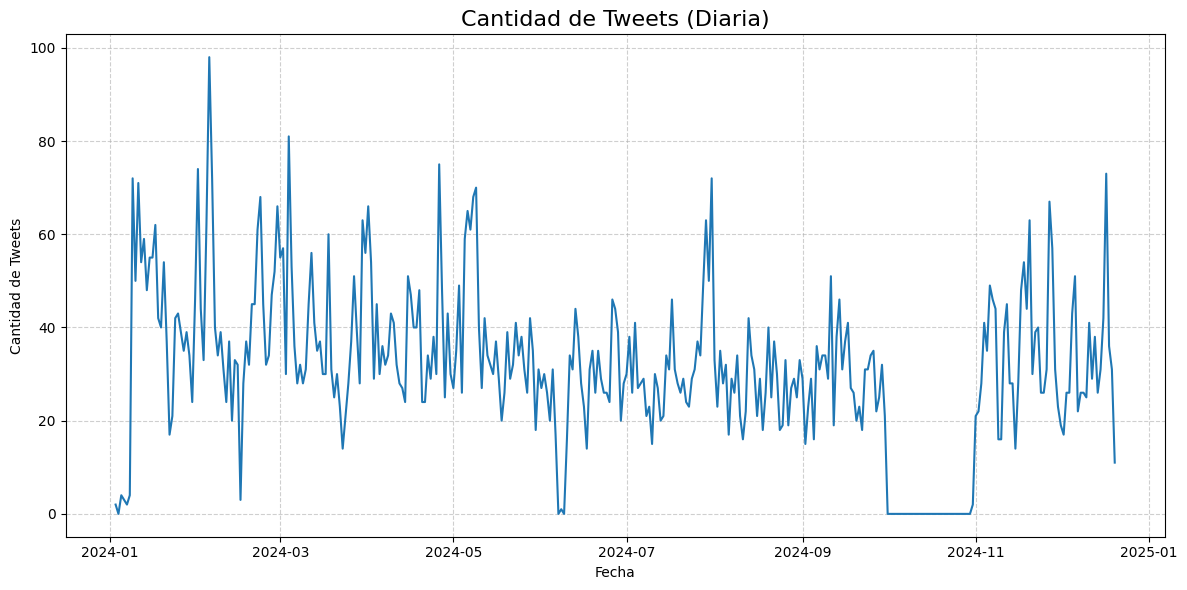

In [19]:
plot_tweets_by_time(df, date_col='date', period='D')

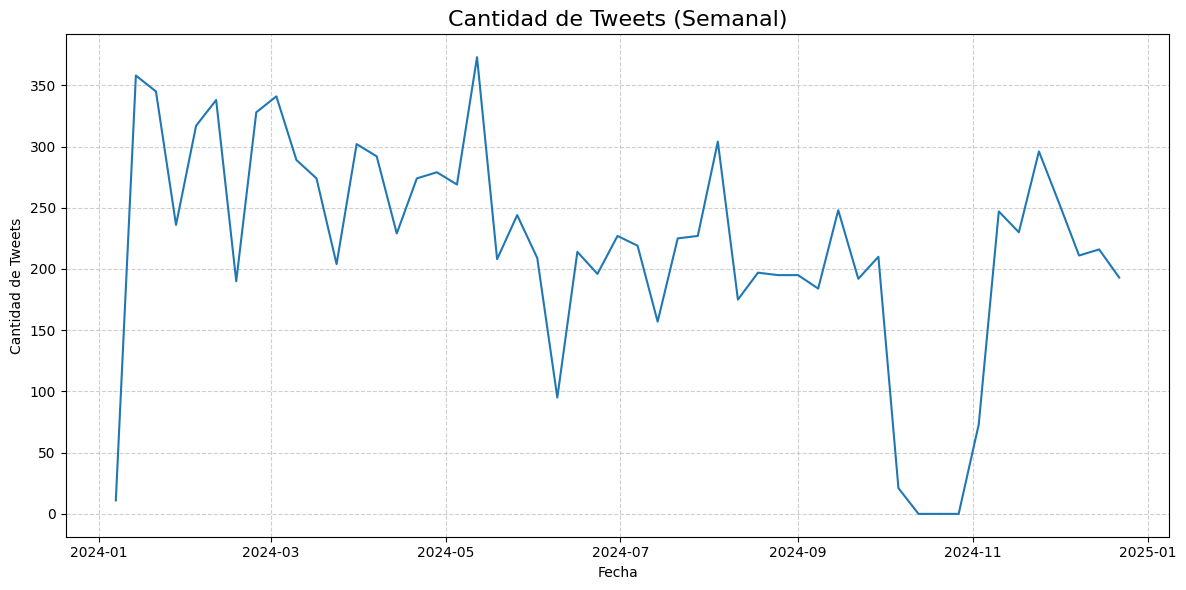

In [20]:
plot_tweets_by_time(df, date_col='date', period='W')

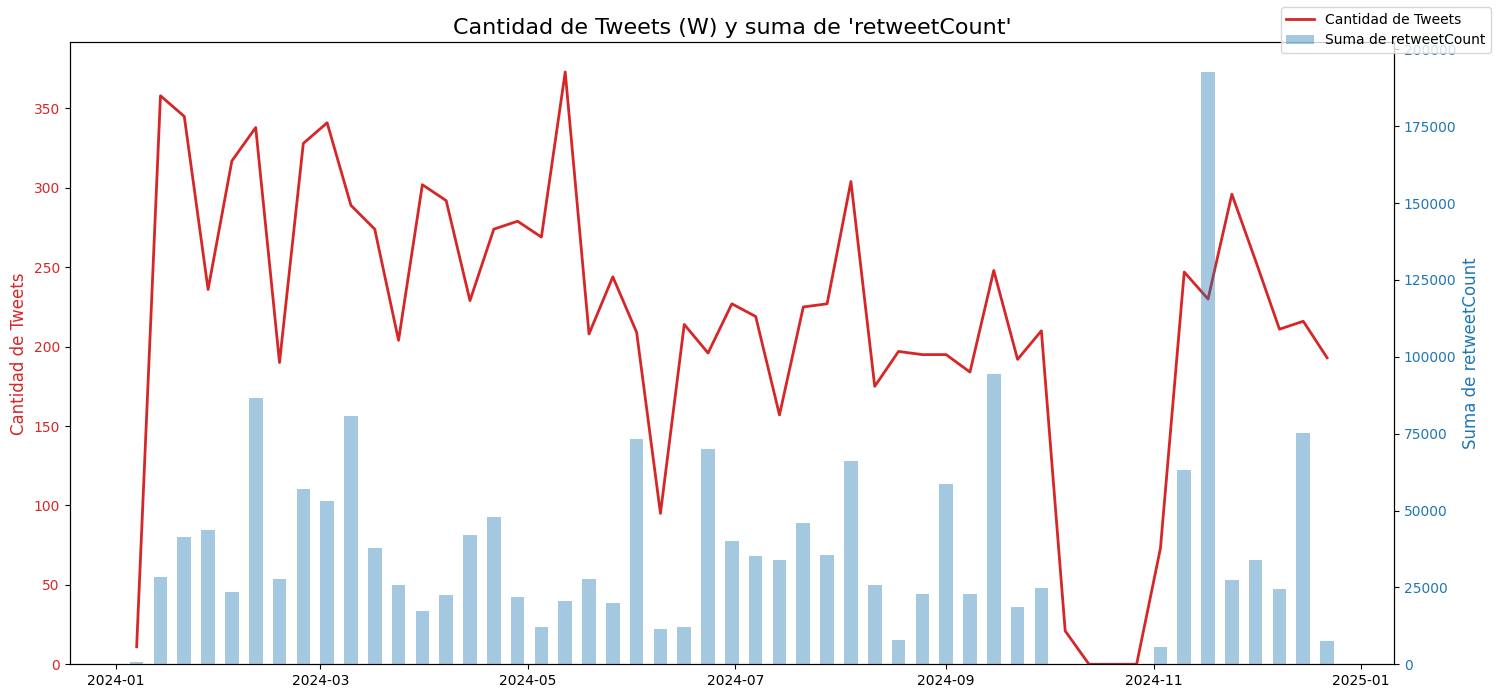

In [21]:
plot_tweets_and_metric(
    df,
    date_col='date',
    period='W',
    metric='retweetCount',
    bar_width=4.0
)

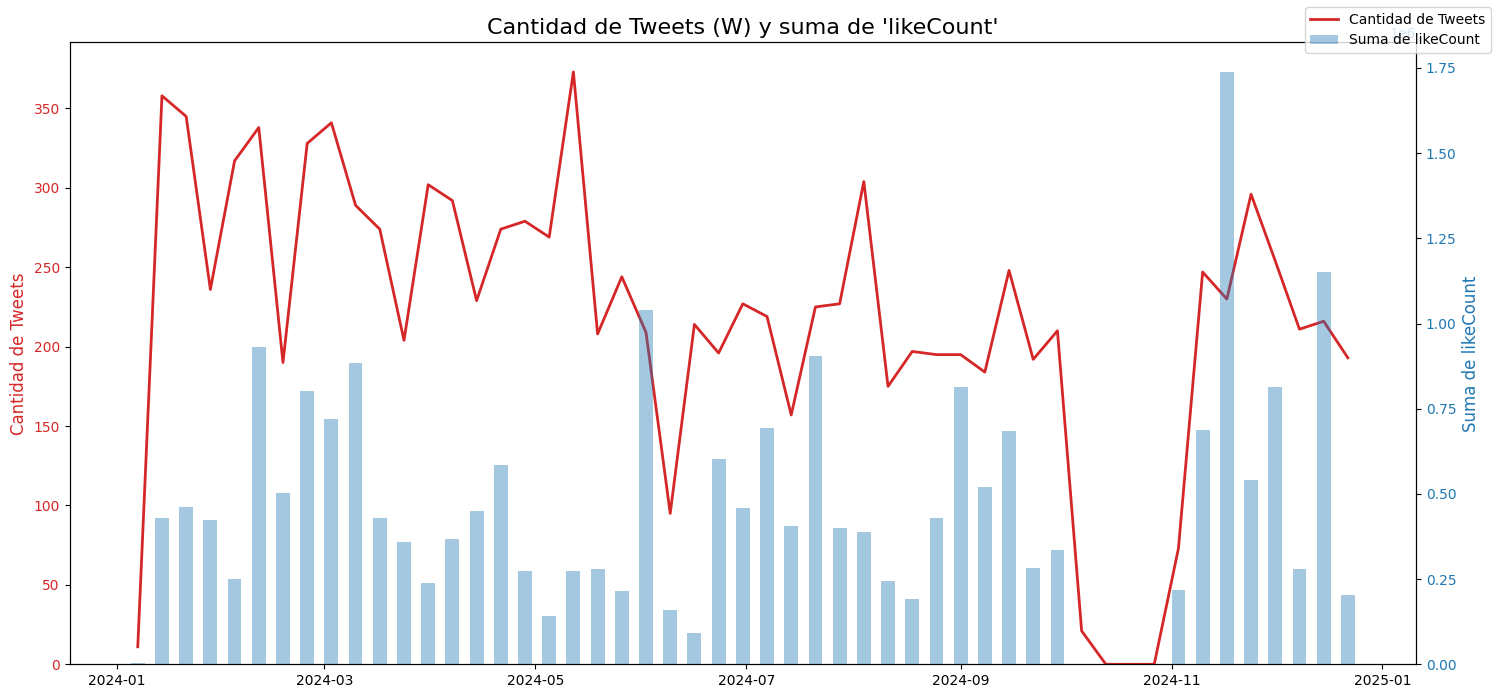

In [22]:
plot_tweets_and_metric(
    df,
    date_col='date',
    period='W',
    metric='likeCount',
    bar_width=4.0
)

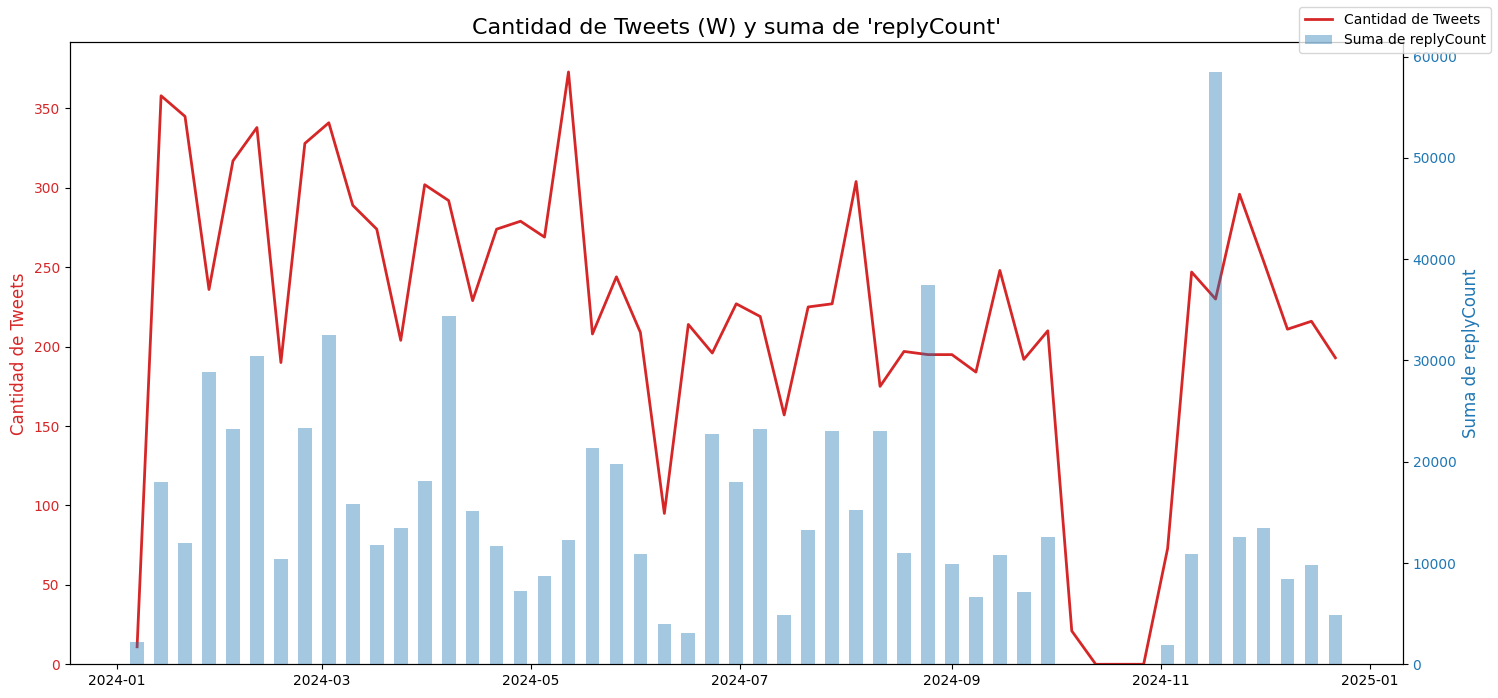

In [23]:
plot_tweets_and_metric(
    df,
    date_col='date',
    period='W',
    metric='replyCount',
    bar_width=4.0
)

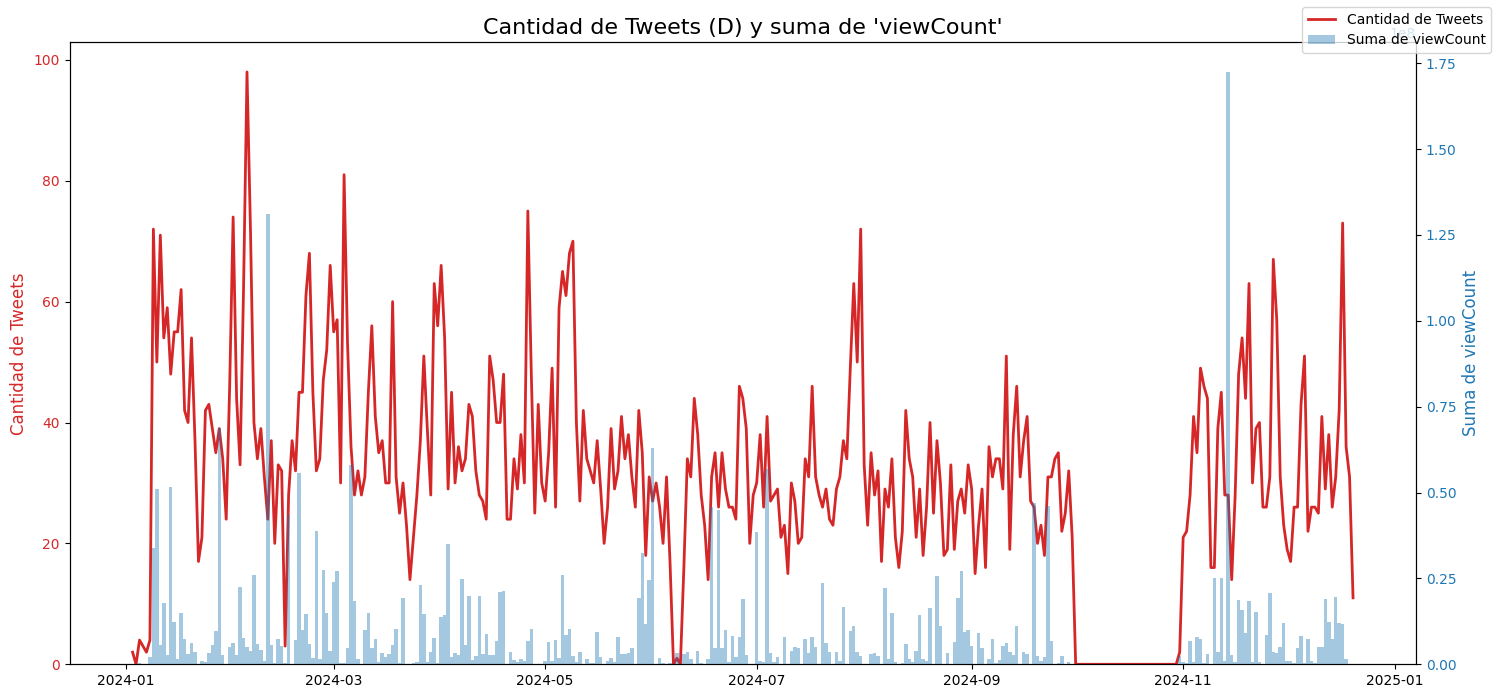

In [24]:
plot_tweets_and_metric(
    df,
    date_col='date',
    period='D',
    metric='viewCount',
    bar_width=1.0
)

#### Provincias

In [25]:
pcia_counts = df['pcia'].explode().value_counts()
pcia_counts_df = pcia_counts.reset_index()

total_tweets = pcia_counts_df['count'].sum()
print("=== ANÁLISIS DE LA DISTRIBUCIÓN ESPACIAL DE TWEETS ===\n")
print(f"Total de tweets con provincia: {total_tweets:,}")
print(f"Número de provincias: {len(pcia_counts_df)}")

# Calcular frecuencias relativas (porcentajes)
pcia_counts_df['freq_relativa'] = (pcia_counts_df['count'] / total_tweets) * 100
pcia_counts_df['freq_acumulada'] = pcia_counts_df['freq_relativa'].cumsum()

print("\n=== DISTRIBUCIÓN POR FRECUENCIAS ===")
print(pcia_counts_df[['pcia', 'count', 'freq_relativa', 'freq_acumulada']].round(2))

print(f"\n=== ANÁLISIS DE CONCENTRACIÓN ===")
print(f"{pcia_counts_df.pcia[0]} representa el {pcia_counts_df.loc[0, 'freq_relativa']:.1f}% del total")
print(f"Top 3 provincias representan el {pcia_counts_df.head(3)['freq_relativa'].sum():.1f}% del total")
print(f"Top 5 provincias representan el {pcia_counts_df.head(5)['freq_relativa'].sum():.1f}% del total")

=== ANÁLISIS DE LA DISTRIBUCIÓN ESPACIAL DE TWEETS ===

Total de tweets con provincia: 9,920
Número de provincias: 23

=== DISTRIBUCIÓN POR FRECUENCIAS ===
                   pcia  count  freq_relativa  freq_acumulada
0          buenos aires   8400          84.68           84.68
1                  caba    475           4.79           89.47
2             argentina    319           3.22           92.68
3                chubut    190           1.92           94.60
4              santa fe    131           1.32           95.92
5             rio negro     86           0.87           96.78
6      tierra del fuego     75           0.76           97.54
7               tucuman     59           0.59           98.14
8            entre rios     49           0.49           98.63
9            santa cruz     46           0.46           99.09
10             la pampa     25           0.25           99.34
11              cordoba     18           0.18           99.53
12            catamarca     16        

In [26]:
# Instalación de librerías necesarias (ejecutar en Colab)
#!pip install folium geopandas

import pandas as pd
import folium
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlretrieve
import json

# Crear mapas
# 1. Mapa básico con folium
def crear_mapa_basico():
    # Coordenadas aproximadas de provincias argentinas para marcadores
    coordenadas = {
        'buenos aires': [-36.6769, -60.5588],
        'caba': [-34.6118, -58.3960],
        'santa fe': [-31.6333, -60.7000],
        'cordoba': [-31.4201, -64.1888],
        'mendoza': [-32.8895, -68.8458],
        'tucuman': [-26.8083, -65.2176],
        'entre rios': [-31.7333, -60.5000],
        'chubut': [-43.3002, -65.1023],
        'rio negro': [-40.8135, -62.9967],
        'santa cruz': [-48.8667, -69.2167],
        'tierra del fuego': [-54.8000, -68.3000],
        'la pampa': [-36.6167, -64.2833],
        'catamarca': [-28.4696, -65.7852],
        'salta': [-24.7821, -65.4232],
        'misiones': [-27.3621, -55.9008],
        'corrientes': [-27.4806, -58.8341],
        'neuquen': [-38.9516, -68.0591],
        'santiago del estero': [-27.7824, -64.2478]
    }

    # Crear mapa centrado en Argentina
    m = folium.Map(location=[-38.4161, -63.6167], zoom_start=5)

    # Añadir marcadores proporcionales
    for idx, row in pcia_counts_df.iterrows():
        prov = row['pcia']
        if prov in coordenadas and prov not in ['argentina', 'antartida']:
            coords = coordenadas[prov]
            popup_text = f"{prov.title()}<br>Tweets: {row['count']:,}<br>Porcentaje: {row['freq_relativa']:.1f}%"

            # Tamaño del marcador proporcional a los tweets (con escala logarítmica para mejor visualización)
            radius = max(5, min(50, np.log10(row['count']) * 10))

            folium.CircleMarker(
                location=coords,
                radius=radius,
                popup=popup_text,
                color='red',
                fill=True,
                fillColor='red',
                fillOpacity=0.6,
                weight=2
            ).add_to(m)

    return m

# Crear el mapa
mapa = crear_mapa_basico()
mapa



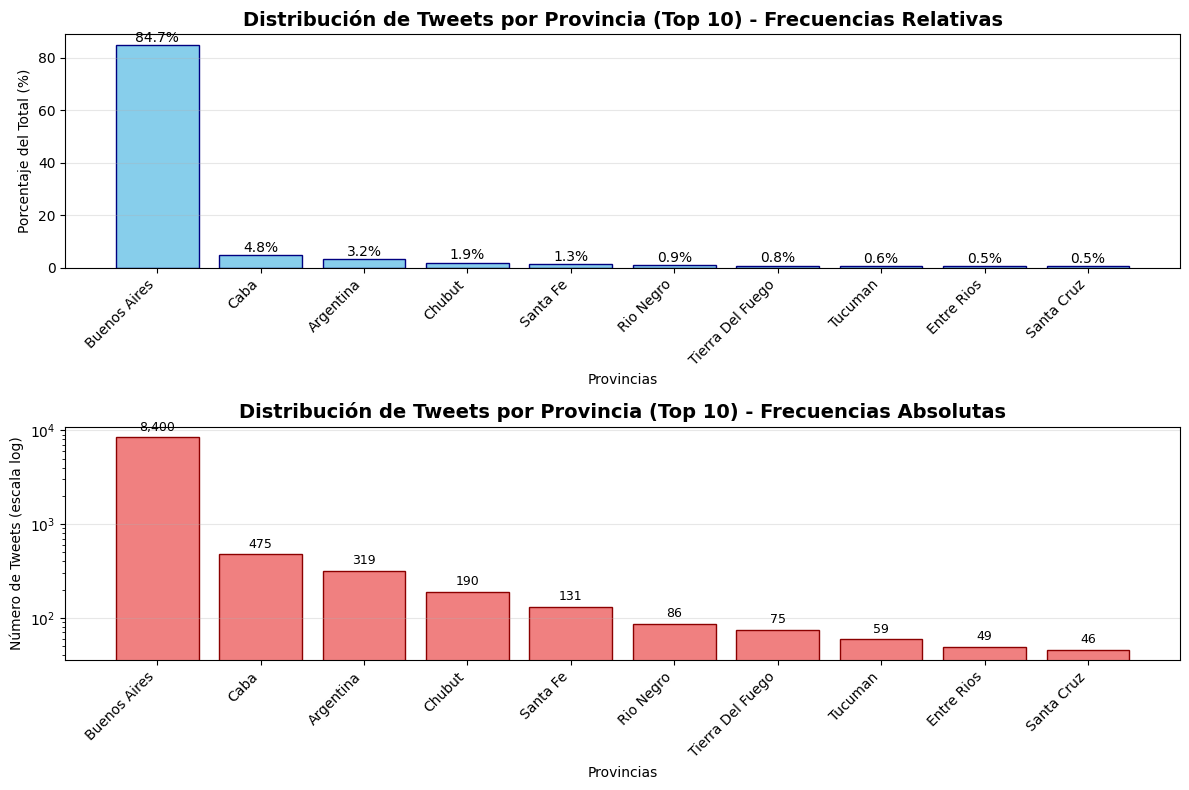

In [27]:
# Gráfico de barras complementario
plt.figure(figsize=(12, 8))
top_10 = pcia_counts_df.head(10)

# Gráfico de frecuencias relativas
plt.subplot(2, 1, 1)
bars = plt.bar(range(len(top_10)), top_10['freq_relativa'], color='skyblue', edgecolor='navy')
plt.title('Distribución de Tweets por Provincia (Top 10) - Frecuencias Relativas', fontsize=14, fontweight='bold')
plt.xlabel('Provincias')
plt.ylabel('Porcentaje del Total (%)')
plt.xticks(range(len(top_10)), [p.title() for p in top_10['pcia']], rotation=45, ha='right')

# Añadir valores en las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}%', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Gráfico de frecuencias absolutas (logarítmico para mejor visualización)
plt.subplot(2, 1, 2)
bars2 = plt.bar(range(len(top_10)), top_10['count'], color='lightcoral', edgecolor='darkred')
plt.title('Distribución de Tweets por Provincia (Top 10) - Frecuencias Absolutas', fontsize=14, fontweight='bold')
plt.xlabel('Provincias')
plt.ylabel('Número de Tweets (escala log)')
plt.yscale('log')
plt.xticks(range(len(top_10)), [p.title() for p in top_10['pcia']], rotation=45, ha='right')

# Añadir valores en las barras
for i, bar in enumerate(bars2):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height * 1.1,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Outliers

Estos outliers son tweets que tuvieron muchas interacciones, por lo tanto, de acuerdo a cómo realicemos el análisis lo enunciado en estos tweets podría tener más peso ya que más personas lo han visto y se han expresado de alguna manera ante él (siendo, sin dudas, expresiones de apoyo los likes y retweet).

Si hay algún análisis que querramos realizar para el cual los valores de estos outliers, que son mucho más altos, nos podemos plantear transformar las variables, probablemente en escala logarítmica, o cambiar de modelo. Si los descartamos igual deberíamos realizar un análisis sobre los outliers puesto que acarrean información muy relevante para abordar nuestra problemática.

Puede ocurrir además que algunos tweets no estén relacionados con la temática que nos interesa abordar, esto implica que los descartemos previo a realizar nuestros estudios.

#### Nube de hashtags

In [28]:
df['hashtags'].explode().value_counts().head(20)

,count
hashtags,
GranHermano,156
Obesidad,50
obesidad,48
granhermano,39
Salud,37
Negocios,23
GranFuria,17
cuestiondepeso,17
Gobierno,16


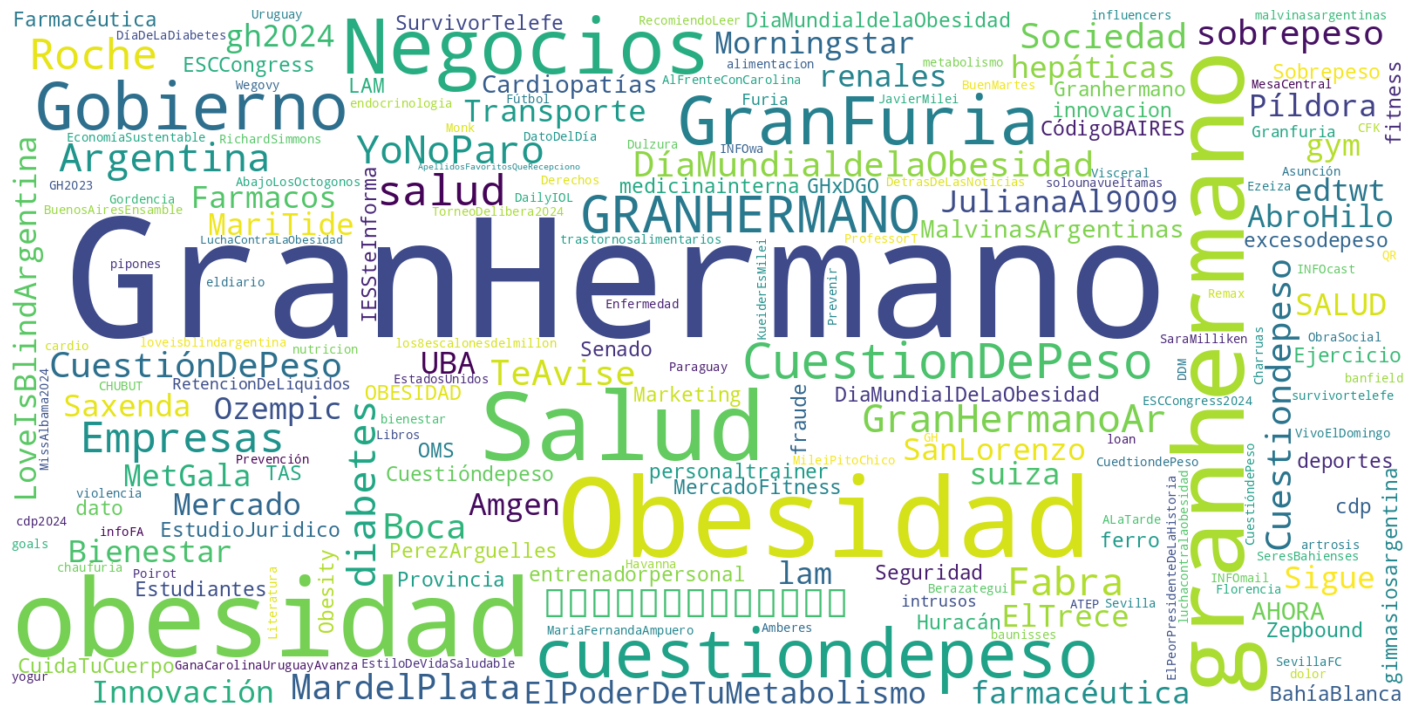

In [29]:
from wordcloud import WordCloud

hashtag_counts = df['hashtags'].explode().value_counts()

wordcloud = WordCloud(width=1600,
                      height=800,
                      background_color='white',
                      colormap='viridis').generate_from_frequencies(hashtag_counts)

# Mostramos la imagen generada
plt.figure(figsize=(18, 12))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Contenido de tipo texto

#### Ejercicio 5

* a. Identificar las palabras más frecuentes incluyendo stopwords (utilizar gráficos según considere necesario).
* b. Identificar las palabras más frecuentes sin incluir stopwords (utilizar gráficos según considere necesario).
* c. Calcular la cantidad de palabras considerando stopwords por tweet en una nueva variable. Luego otra sin considerar las stopwords. Graficar las distribuciones. Realice una interpretación de los graficos.
* d. Agrupar los tweets por provincia o mes y observar posibles diferencias en los términos más frecuentes entre lugares o períodos.

¿Qué otras variables se les ocurre incluir o generar a partir de los análisis realizados? ¿Qué procesos de curación de datos considera idóneos para implementar en el próximo práctico?


In [30]:
%%capture
!python -m spacy download es_core_news_sm

In [31]:
# Descargamos stopwords en español (pueden usar las de nltk, spacy, etc)
#!pip install nltk spacy
#!python -m spacy download es_core_news_sm

import nltk
from nltk.corpus import stopwords
import spacy

nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

# Cargamos modelo de spaCy para español
nlp = spacy.load('es_core_news_sm')

# Removemos stopwords y palabras con menos de 3 caracteres (esta decisión es propia, pueden modificarla)
def remover_stopwords(texto):
    doc = nlp(texto)
    tokens = [token.text for token in doc if token.text not in stop_words and len(token.text) > 2]
    return ' '.join(tokens)

df['texto_limpio'] = df['rawContent'].apply(remover_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [32]:
# Calculamos la longitud de cada mensaje
df['longitud_mensaje'] = df['texto_limpio'].str.len()  #caracteres
df['cantidad_palabras'] = df['texto_limpio'].str.split().str.len()  #palabras

<Axes: xlabel='longitud_mensaje', ylabel='Count'>

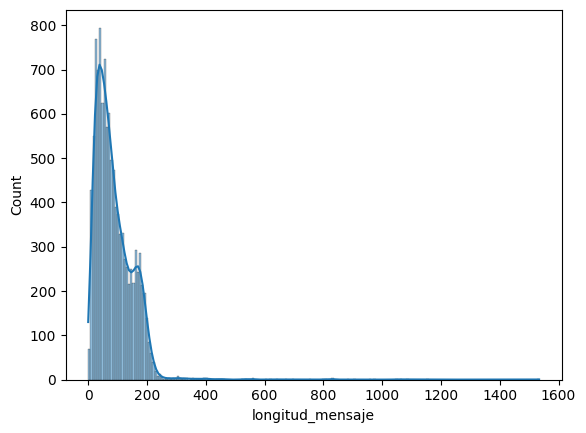

In [33]:
sns.histplot(df['longitud_mensaje'], kde=True)

<Axes: xlabel='cantidad_palabras', ylabel='Count'>

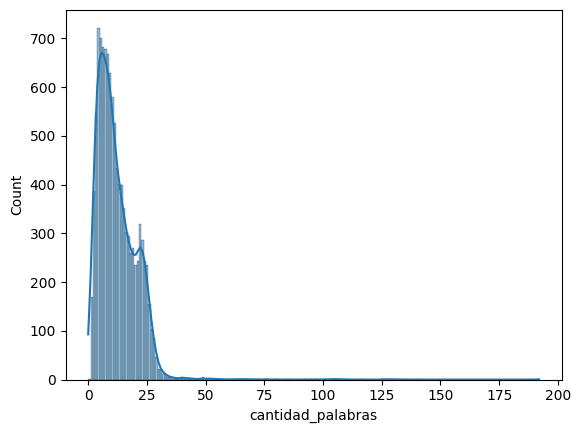

In [34]:
sns.histplot(df['cantidad_palabras'], kde=True)

#### a y b)

In [35]:
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
nltk.download('punkt_tab')

df['tokens_with_stopwords'] = df['rawContent'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


20 palabras más comunes:
[('de', 10528), (',', 10231), ('que', 8490), ('.', 8382), ('la', 7336), ('y', 6471), ('a', 5203), ('no', 4392), ('el', 4324), ('en', 3624), ('es', 3592), ('con', 3242), ('un', 2914), ('los', 2369), ('obesidad', 2337), ('se', 2325), ('una', 2264), ('link_url', 2203), ('?', 2200), ('lo', 2035)]


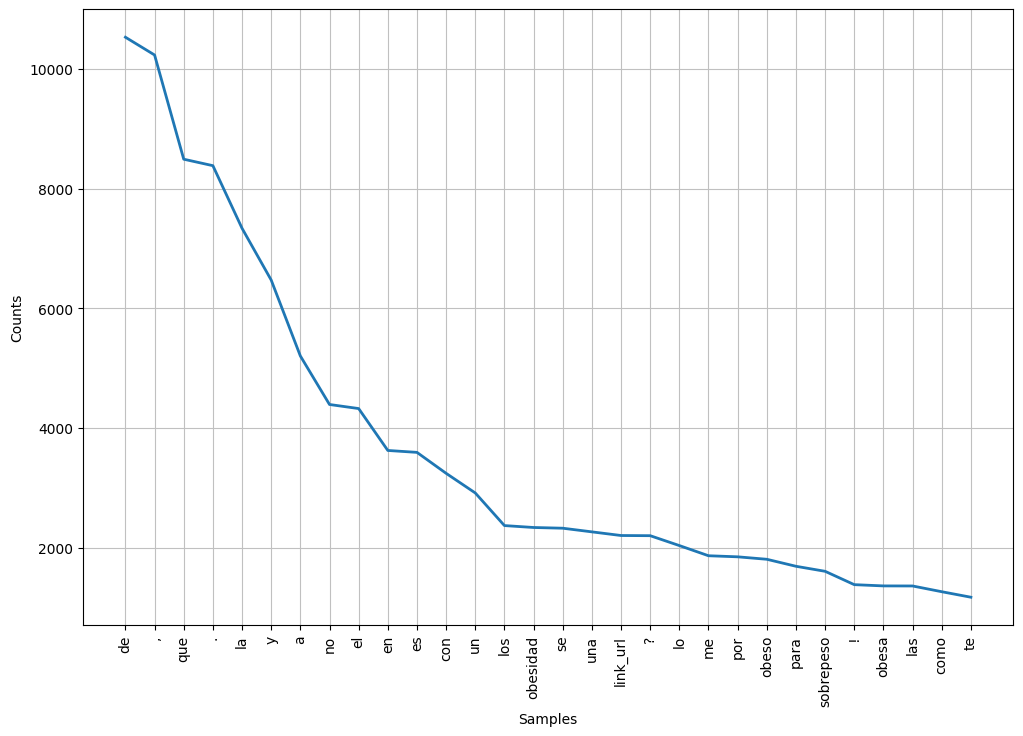

In [36]:
from nltk.probability import FreqDist

# 1. Crear una única lista con todos los tokens de todos los textos
todos_los_tokens = df['tokens_with_stopwords'].explode().to_list()

# 2. Calcular la frecuencia de cada token con FreqDist
freq_dist = FreqDist(todos_los_tokens)

# 3. Mostrar las 20 palabras más comunes
print("20 palabras más comunes:")
print(freq_dist.most_common(20))

# 4. Graficar las 30 palabras más comunes
plt.figure(figsize=(12, 8))
freq_dist.plot(30, cumulative=False)
plt.show()

20 palabras más comunes:
[('obesidad', 2356), ('link_url', 2208), ('obeso', 1818), ('sobrepeso', 1622), ('obesa', 1384), ('...', 922), ('ser', 820), ('gordura', 736), ('obesos', 567), ('gente', 506), ('gordo', 482), ('gorda', 462), ('vos', 437), ('puede', 415), ('bien', 403), ('tener', 400), ('hace', 395), ('años', 388), ('peso', 387), ('así', 363)]


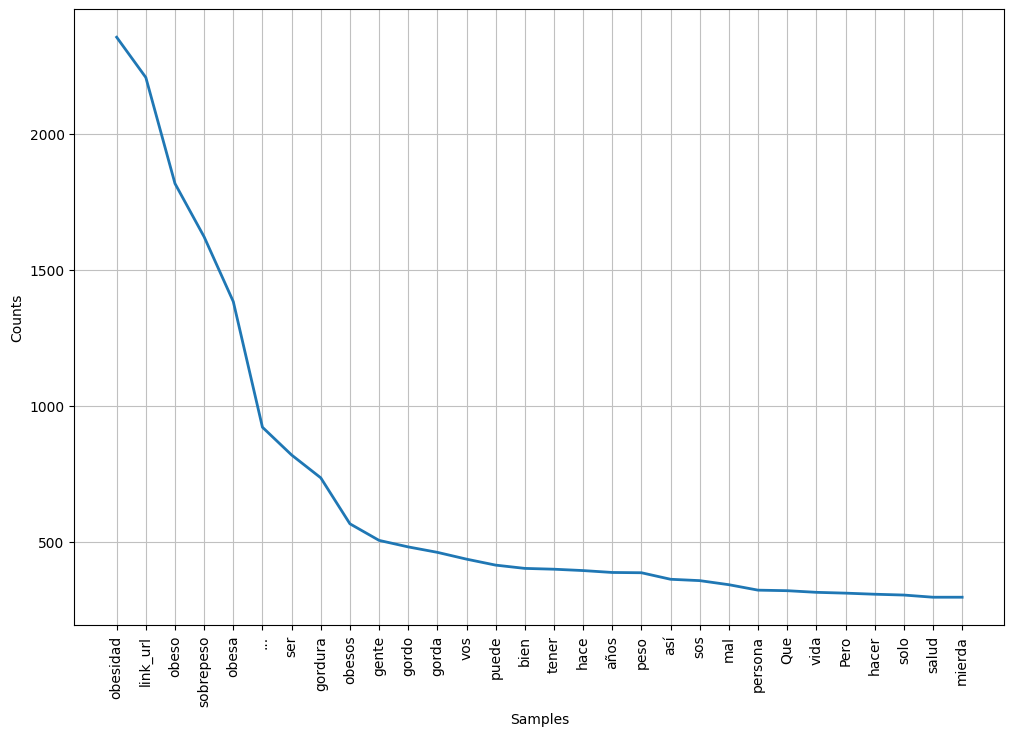

In [37]:
df['tokens_no_stopwords'] = df['texto_limpio'].apply(word_tokenize)

# 1. Crear una única lista con todos los tokens de todos los textos
todos_los_tokens = df['tokens_no_stopwords'].explode().to_list()

# 2. Calcular la frecuencia de cada token con FreqDist
freq_dist = FreqDist(todos_los_tokens)

# 3. Mostrar las 20 palabras más comunes
print("20 palabras más comunes:")
print(freq_dist.most_common(20))

# 4. Graficar las 30 palabras más comunes
plt.figure(figsize=(12, 8))
freq_dist.plot(30, cumulative=False)
plt.show()

#### c)

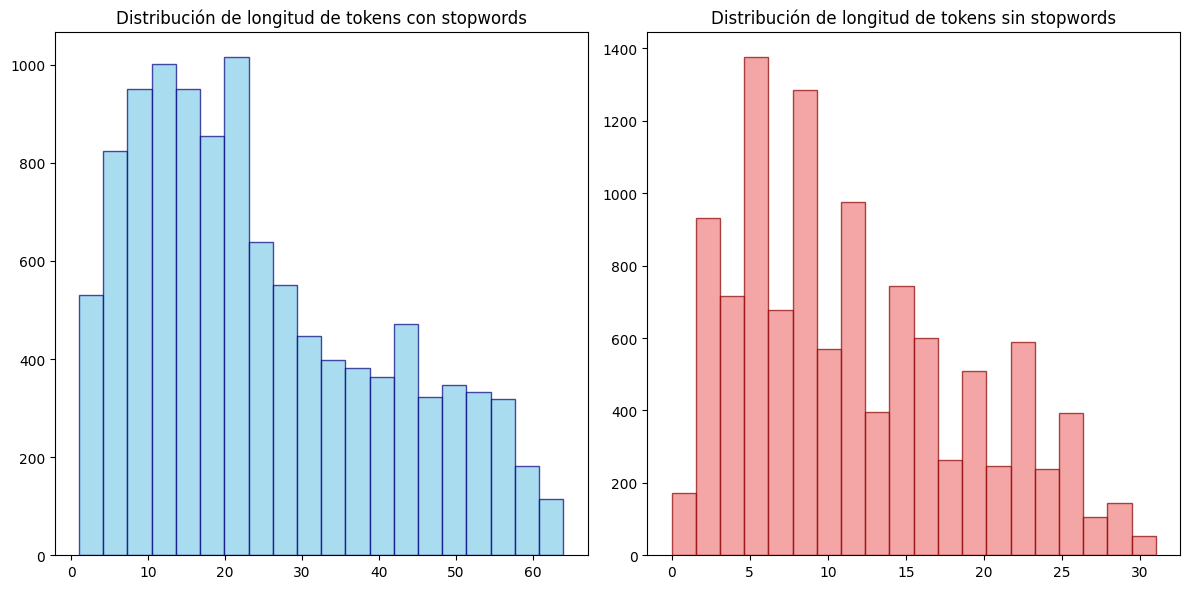

In [38]:
df['len_tokens_with_stopwords'] = df['tokens_with_stopwords'].str.len()
df['len_tokens_no_stopwords'] = df['tokens_no_stopwords'].str.len()

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].hist(
    #df['len_tokens_with_stopwords'],
    df['len_tokens_with_stopwords'][df['len_tokens_with_stopwords'] < df['len_tokens_with_stopwords'].quantile(0.99)],
    bins=20,
    color='skyblue',
    edgecolor='navy',
    alpha=0.7
)
axs[1].hist(
    #df['len_tokens_no_stopwords'],
    df['len_tokens_no_stopwords'][df['len_tokens_no_stopwords'] < df['len_tokens_no_stopwords'].quantile(0.99)],
    bins=20,
    color='lightcoral',
    edgecolor='darkred',
    alpha=0.7
)

axs[0].set_title('Distribución de longitud de tokens con stopwords')
axs[1].set_title('Distribución de longitud de tokens sin stopwords')

plt.tight_layout()
plt.show()

In [39]:
df[['len_tokens_no_stopwords', 'len_tokens_with_stopwords']].describe()

,len_tokens_no_stopwords,len_tokens_with_stopwords
count,11111.000000,11111.000000
mean,12.159752,25.683737
std,8.900335,19.243180
min,0.000000,1.000000
25%,6.000000,12.000000
50%,10.000000,21.000000
75%,17.000000,37.000000
max,192.000000,394.000000


Casi la mitad de palabras son stopwords.

#### d)

<Axes: title={'center': 'Document Count per Month'}, xlabel='mes'>

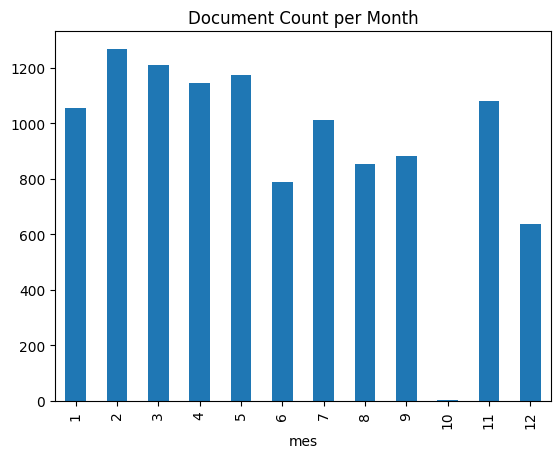

In [40]:
df.groupby('mes', observed=True).size().plot(kind='bar', title='Document Count per Month')

<Axes: title={'center': 'Likes per month'}, xlabel='mes'>

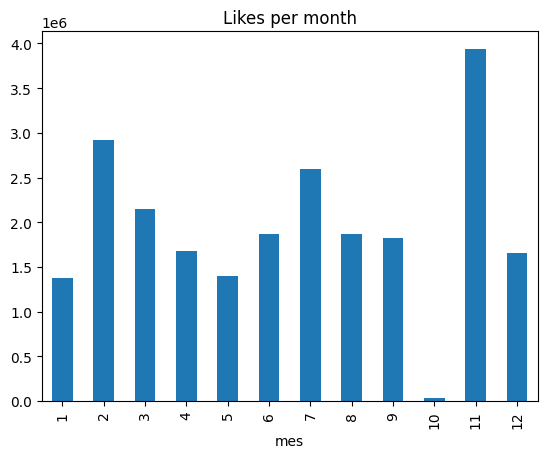

In [41]:
df.groupby('mes', observed=True).likeCount.sum().plot(kind='bar', title='Likes per month')

<Axes: title={'center': 'Likes per month'}, xlabel='mes'>

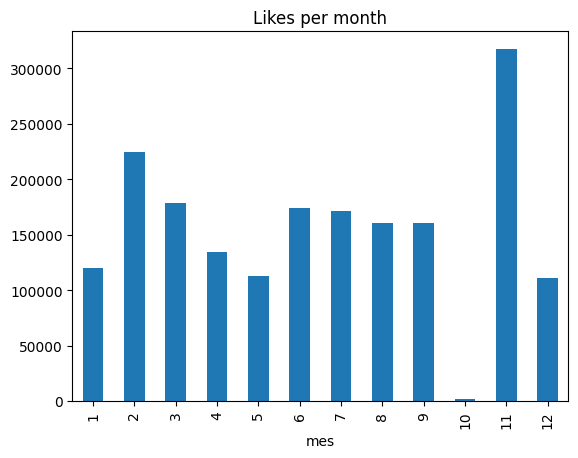

In [42]:
df.groupby('mes', observed=True).retweetCount.sum().plot(kind='bar', title='Likes per month')

<Axes: title={'center': 'Likes per month'}, xlabel='mes'>

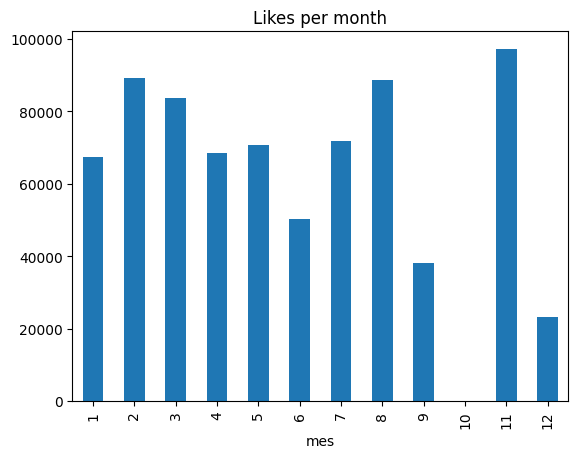

In [43]:
df.groupby('mes', observed=True).replyCount.sum().plot(kind='bar', title='Likes per month')

In [44]:
# Explode the list of tokens into separate rows
df_exploded = df.explode('texto_limpio_tokens')

# Group by month and token, then count occurrences
# Explicitly use observed=True to silence FutureWarning
token_counts = df_exploded.groupby(['mes', 'texto_limpio_tokens'], observed=True).size().reset_index(name='count')

# Function to get the top N tokens for each month and return as a Series for unstacking
def get_top_n_tokens_for_pivot(group, n=20):
    # Get the top N tokens
    top_n = group.nlargest(n, 'count')[['texto_limpio_tokens', 'count']]

    # Convert to list of (token, count) tuples
    token_list = list(top_n.itertuples(index=False, name=None))

    # Pad with (None, None) if less than N tokens to ensure consistent length for all months
    padded_tokens = token_list + [(None, None)] * (n - len(token_list))

    # Return as a Series where index represents the rank
    return pd.Series(padded_tokens)

# Apply the function to each month group
# Pass include_groups=False to silence DeprecationWarning
top_tokens_wide = token_counts.groupby('mes', observed=True).apply(get_top_n_tokens_for_pivot, include_groups=False)

top_tokens_wide.T

KeyError: 'texto_limpio_tokens'

In [ ]:
df.explode('pcia').groupby('pcia', observed=True).size().plot(kind='bar', title='Document Count per Province')

In [ ]:
df_exploded = df.explode("pcia")

df_exploded = df_exploded.explode('texto_limpio_tokens')

token_counts = df_exploded.groupby(['pcia', 'texto_limpio_tokens'], observed=True).size().reset_index(name='count')

top_tokens_wide = token_counts.groupby('pcia', observed=True).apply(get_top_n_tokens_for_pivot, include_groups=False)

top_tokens_wide.T

#### Análisis de tópicos

In [ ]:
%%capture
!pip install bertopic sentence-transformers

In [ ]:
%%capture
!pip install pysentimiento

In [ ]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
import nltk
from nltk.corpus import stopwords
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from bertopic import BERTopic

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import string
import re

# dataset temporal para realizar el análisis
temp_topics = df.copy()

def limpiar_texto(texto: str) -> str:
    """
    Limpia texto de redes sociales con varias reglas.
    """
    # 0. Convertir a minúsculas
    texto = texto.lower()

    # 1. Eliminar URLs
    texto = re.sub(r'\b(?:https?://|www\.)\S+\b', '', texto)

    # 2. Eliminar menciones de usuario (@usuario)
    texto = re.sub(r'@\w+', '', texto)

    # 3. Conservar texto de hashtags, pero sin el '#'
    texto = re.sub(r'#(\w+)', r'\1', texto)

    # 4. Colapsar repeticiones de >2 caracteres (ej: holaaa -> holaa)
    texto = re.sub(r'(.)\1{2,}', r'\1\1', texto)

    # 5. Eliminar cualquier token que termine en '.com'
    texto = re.sub(r'\b\S+\.com\b', '', texto)

    # 6. Recortar espacios sobrantes
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# Creamos el set de puntuación una sola vez para eficiencia.
# Añadimos los caracteres de puntuación Unicode comunes en español.
PUNTUACION_COMPLETA = string.punctuation + '¿¡—…'
CARACTERES_NO_UTILES_PATTERN = r'^[\s' + re.escape(PUNTUACION_COMPLETA) + r']+$'

def es_valido(texto: str) -> bool:
    """
    Devuelve True si el texto NO está compuesto ÚNICAMENTE de espacios
    y signos de puntuación (ASCII + Unicode común).
    """
    if not isinstance(texto, str) or not texto.strip():
        return False

    # re.fullmatch comprueba si TODA la cadena coincide con el patrón.
    # Si coincide (es inútil), la función devuelve False.
    # Si no coincide (es útil), devuelve True.
    return not bool(re.fullmatch(CARACTERES_NO_UTILES_PATTERN, texto))

print("Antes:", temp_topics.shape, "documentos")

temp_topics.drop_duplicates(subset=['rawContent'], inplace=True)

temp_topics = temp_topics.dropna(subset=['rawContent'])

temp_topics["cleaned_content"] = temp_topics["rawContent"].apply(limpiar_texto)

mask = temp_topics["cleaned_content"].apply(es_valido)
temp_topics = temp_topics[mask].copy()

print("Después:", temp_topics.shape, "documentos válidos")

Antes: (11111, 22) documentos
Después: (10974, 23) documentos válidos


In [ ]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
content = temp_topics["rawContent"].tolist()
content_embeddings = model.encode(content, show_progress_bar=True)
temp_topics[f"feature_embeddings_MiniLM"] = list(content_embeddings)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/343 [00:00<?, ?it/s]

In [ ]:
UMAP_NEIGHBORS=20
UMAP_COMPONENTS=150
HDBSCAN_SIZE=150

HDBSCAN_METRIC='euclidean'
CLUSTER_SELECTION_METHOD="eom" #eom, leaf
MIN_SAMPLES=1

CV_MIN_DF=0.2
CV_MAX_DF=0.7

In [ ]:
def calculate_topics(text, embeddings, umap_neighbors=10, umap_components=6, hdbscan_size=5,
                     zeroshot_topic_list=None, zeroshot_min_similarity=0.85, embedding_model=None,
                     seed_topic_list=None):
  # https://umap-learn.readthedocs.io/en/latest/parameters.html
  # low values of n_neighbors will force UMAP to concentrate on very local structure (potentially to the detriment of the big picture)
  # low values of min_dist will result in clumpier embeddings. This can be useful if you are interested in clustering, or in finer topological structure.
  # If you are interested in (density based) clustering, or other machine learning techniques, it can be beneficial to pick a larger embedding dimension (say 10, or 50)
  # metrics: euclidean, coisne, manhattan, chebishev, minkowski, etc.
  umap_model = UMAP(n_neighbors=umap_neighbors, n_components=umap_components, min_dist=0.0, metric='cosine', random_state=42)

  # https://hdbscan.readthedocs.io/en/latest/parameter_selection.html
  # The default method is 'eom' for Excess of Mass, has a tendency to pick one or two large clusters and then a number of small extra clusters.
  # Instead, a better option is to select 'leaf' as a cluster selection method. This will select leaf nodes from the tree.
  hdbscan_model = HDBSCAN(min_cluster_size=hdbscan_size,
                          metric=HDBSCAN_METRIC,
                          cluster_selection_method=CLUSTER_SELECTION_METHOD,
                          min_samples=MIN_SAMPLES,
                          prediction_data=True)

  spanish_stopwords = set(stopwords.words('spanish'))
  custom_stopwords = {'ejemplo','ser','estar','así','solo','vez','mientras','ud','si','aquí','eh', 'bueno', 'va', 'ahí','vamos','bien','ver',
                      'entonces','día','hoy','voy','acá','vol'}
  spanish_stopwords.update(custom_stopwords)
  spanish_stopwords = list(spanish_stopwords)

  vectorizer_model = CountVectorizer(stop_words=spanish_stopwords, min_df=CV_MIN_DF, max_df=CV_MAX_DF, ngram_range=(1, 2))

  ctfidf_model = ClassTfidfTransformer(
      bm25_weighting=False,
      reduce_frequent_words=False
  )


  # Agregar diferentes representaciones
  # KeyBERT
  keybert_model = KeyBERTInspired()
  # MMR
  mmr_model = MaximalMarginalRelevance(diversity=0.5)

  representation_model = {
      #"KeyBERT": keybert_model,
      "MMR": mmr_model,
  }

  topic_model = BERTopic(
  # Modelos del pipeline
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  vectorizer_model=vectorizer_model,
  representation_model=representation_model,
  ctfidf_model=ctfidf_model,
  zeroshot_topic_list=zeroshot_topic_list,
  zeroshot_min_similarity=zeroshot_min_similarity,
  seed_topic_list=seed_topic_list,
  # Otras opciones
  top_n_words=10,
  verbose=True,
  calculate_probabilities=True
)

  topics, probs = topic_model.fit_transform(text, embeddings)
  return topics, probs, topic_model

In [ ]:
content = temp_topics["rawContent"].tolist()
content_embeddings = temp_topics[f"feature_embeddings_MiniLM"].tolist()
content_embeddings = np.array(content_embeddings)

topics, probs, topic_model = calculate_topics(content,
                                              content_embeddings,
                                              umap_neighbors=UMAP_NEIGHBORS,
                                              umap_components=UMAP_COMPONENTS,
                                              hdbscan_size=HDBSCAN_SIZE,
                                              embedding_model=model,
                                              )

2025-06-22 15:30:50,907 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-22 15:32:00,478 - BERTopic - Dimensionality - Completed ✓
2025-06-22 15:32:00,487 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-22 15:32:28,566 - BERTopic - Cluster - Completed ✓
2025-06-22 15:32:28,574 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-22 15:32:36,115 - BERTopic - Representation - Completed ✓


In [ ]:
hierarchical_topics = topic_model.hierarchical_topics(content)

100%|██████████| 15/15 [00:00<00:00, 206.39it/s]


In [ ]:
import textwrap

# El ancho en caracteres antes de cortar la línea
wrap_width = 80

# 1. Pre-procesamos la lista de documentos para añadir saltos de línea HTML
# Usamos textwrap para cortar y .replace() para que el gráfico lo entienda
wrapped_content = [textwrap.fill(doc, width=wrap_width).replace('\n', '<br>') for doc in content]

# 2. Ahora generamos el gráfico usando esta nueva lista
reduced_content_embeddings = UMAP(
    n_neighbors=10,
    n_components=2,
    min_dist=0.0,
    metric='cosine'
).fit_transform(content_embeddings)

topic_model.visualize_documents(
    wrapped_content, # <--- Usamos la lista con el texto ya ajustado
    reduced_embeddings=reduced_content_embeddings,
    custom_labels=True,
    hide_annotations=False
)

In [ ]:
topic_model.visualize_barchart(top_n_topics=18, n_words=15, autoscale=True)

In [ ]:
# The higher the score, the more representative a word to the topic is.
topic_model.visualize_term_rank(log_scale=True)

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.get_topic_info().drop(columns=["Representative_Docs"])

,Topic,Count,Name,Representation,MMR
0,-1,5218,-1_granhermano_furia_gato_salud,"[granhermano, furia, gato, salud, hijos, madre...","[granhermano, gato, salud, madre, video, corre..."
1,0,967,0_siento_siento obesa_comí_feliz,"[siento, siento obesa, comí, feliz, gym, seman...","[siento, siento obesa, feliz, gym, semana, piz..."
2,1,550,1_enfermedad_obesidad enfermedad_salud_enferme...,"[enfermedad, obesidad enfermedad, salud, enfer...","[anorexia, normalizar, problemas salud, romant..."
3,2,549,2_diabetes_obesidad link_url_link_url link_url...,"[diabetes, obesidad link_url, link_url link_ur...","[obesidad link_url, link_url link_url, mundial..."
4,3,488,3_obeso link_url_granhermano link_url_granherm...,"[obeso link_url, granhermano link_url, granher...","[obeso link_url, granhermano link_url, link_ur..."
5,4,484,4_mujer_mujeres_chica_hombres,"[mujer, mujeres, chica, hombres, chicas, mujer...","[mujeres, chica, mujer obesa, lesbiana, flaca,..."
6,5,366,5_imc_gente obesa_comen_obesidad obesidad,"[imc, gente obesa, comen, obesidad obesidad, g...","[gente obesa, gringos, bajo peso, adiposidad, ..."
7,6,335,6_argentina_méxico_argentinos_cáncer sida,"[argentina, méxico, argentinos, cáncer sida, a...","[méxico, argentinos, cáncer sida, economía, ci..."
8,7,320,7_granhermano_madre_concha madre_mata,"[granhermano, madre, concha madre, mata, sergi...","[granhermano, concha madre, nooo, 24, cuestión..."
9,8,290,8_gobierno_política_presidente_libertario,"[gobierno, política, presidente, libertario, m...","[libertario, guerra, pobres, impuestos, congre..."


In [ ]:
topic_model.visualize_distribution(probs[0], min_probability=0.0001)

In [ ]:
# Calculate the topic distributions on a token-level
topic_distr, topic_token_distr = topic_model.approximate_distribution(content, calculate_tokens=True)

100%|██████████| 11/11 [00:04<00:00,  2.24it/s]


In [ ]:
# Visualize the token-level distributions
df = topic_model.visualize_approximate_distribution(content[0], topic_token_distr[0])
df

,Boluda,ahí,dice,que,yo,debería,pesar,43kg,eso,está,para,el,orto,Yo,sé,que,tengo,sobrepeso,por,eso,estoy,empezando,cuidarme,más,para,bajar,de,peso,por,mi,altura,mi,peso,ideal,sería,64
0_obesos_gente_mierda_van,0.134,0.269,0.403,0.403,0.269,0.134,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1_mierda_sos_ahora_dios,0.141,0.282,0.422,0.422,0.282,0.141,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3_kilos_peso_obesa_mal,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.366,0.732,1.097,1.463,1.097,1.097,1.097,1.097,1.463,1.097,0.732,0.366
5_obesas_todas_tipo_cuerpo,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.102,0.205,0.307,0.410,0.307,0.307,0.307,0.307,0.410,0.307,0.205,0.102
6_persona_hacer_puede_cuerpo,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.192,0.384,0.576,0.768,0.576,0.576,0.576,0.576,0.768,0.576,0.384,0.192
13_comida_gente_tan_obesos,0.120,0.241,0.361,0.361,0.241,0.120,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.117,0.234,0.351,0.468,0.351,0.351,0.351,0.351,0.468,0.351,0.234,0.117
15_comida_encima_obesas_obesos,0.149,0.299,0.448,0.448,0.299,0.149,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.226,0.451,0.677,0.902,0.677,0.677,0.677,0.677,0.902,0.677,0.451,0.226
16_gordura_mierda_gordo_dijo,0.127,0.255,0.382,0.382,0.255,0.127,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
17_mas_años_nunca_después,0.147,0.295,0.442,0.442,0.295,0.147,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
18_obesa_obesas_obesos_gordo obeso,0.208,0.415,0.623,0.623,0.415,0.208,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [ ]:
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

In [ ]:
tree = topic_model.get_topic_tree(hierarchical_topics)
print(tree)

.
├─link_url_obesidad_salud_mundo_ahora
│    ├─link_url_mundo_ahora_dijo_re
│    │    ├─■──dijo_mundo_ahora_link_url_mejor ── Topic: 73
│    │    └─link_url_re_veo_gorda_ahora
│    │         ├─■──link_url_gorda_re_mal_tenés ── Topic: 25
│    │         └─link_url_veo_re_peso_ahora
│    │              ├─link_url_veo_re_ahora_vida
│    │              │    ├─■──link_url_peso_vida_re_ahora ── Topic: 32
│    │              │    └─■──link_url_veo_cara_mejor_re ── Topic: 8
│    │              └─■──link_url_veces_van_cosas_después ── Topic: 76
│    └─link_url_obesidad_salud_personas_peso
│         ├─link_url_obesidad_salud_mórbida_obesidad mórbida
│         │    ├─■──link_url_obesidad_obesidad mórbida_problema_vida ── Topic: 49
│         │    └─link_url_obesidad_salud_grasa_años
│         │         ├─■──link_url_obesidad_grasa_salud_dos ── Topic: 50
│         │         └─■──link_url_obesidad_salud_años_problemas ── Topic: 39
│         └─salud_link_url_obesidad_personas_peso
│              ├─■──

In [ ]:
topic_model.visualize_heatmap(n_clusters=8)

#### Red de palabras

In [45]:
#mount google
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [56]:
#load dataset with classification
file_path = "/content/drive/MyDrive/ESTUDIO/DIPLOMATURA/MENTORIAS/PRACTICO_1/base_obesidad_classified.csv"
graph_df = pd.read_csv(file_path)

In [58]:
graph_df = graph_df.rename({'rawContent':'post_content', 'sentiment':'feature_sentiment_classification'}, axis=1)

##### Tokenización

- Se podrían configurar otros tokenizadores
- Revisar la configuración de Spacy

In [60]:
%%capture
!pip install unidecode

In [61]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [62]:
%%capture
!python -m spacy download es_core_news_sm

In [63]:
import spacy
from nltk.corpus import stopwords
from unidecode import unidecode
import re

nlp = spacy.load('es_core_news_sm', disable=['parser','ner'])

def tokenize_and_clean(text, tokenizer="word_tokenize", use_spacy=True, custom_stopwords=None, stopwords_adhoc=None, desired_pos={'NOUN', 'ADJ'}):
    """
    Tokenizes text, filters by POS (NOUN, ADJ, VERB) using spaCy,
    removes stopwords, punctuation, numbers, and converts to lowercase.
    Args:
        text (str): The input text string.
    Returns:
        list: A list of cleaned tokens.
    """

    stop_words = set(stopwords.words('spanish'))
    stop_words.update(custom_stopwords)
    stop_words.update(stopwords_adhoc)


    if pd.isna(text):
        return []
    text = text.lower()
    #quitar urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # quitar menciones y #
    #text = re.sub(r'\@\w+|\#', '', text)
    # quitar puntuación y símbolos especiales
    text = re.sub(r'[^\w\s]', '', text)
    # quitar los números
    text = re.sub(r'\d+', '', text)
    text = unidecode(text)

    if tokenizer == "tweettokenizer":
      from nltk.tokenize import TweetTokenizer
      tokenizer = TweetTokenizer()
      tokens = tokenizer.tokenize(text)
    else:
      from nltk.tokenize import word_tokenize
      tokens = word_tokenize(text)

    cleaned_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]


    if use_spacy:
      # 2) POS-filtering con spaCy
      doc = nlp(" ".join(cleaned_tokens))
      pos_filtered_tokens = [tok.lemma_.lower() for tok in doc if tok.pos_ in desired_pos and tok.text not in stop_words and len(tok.text) > 2 and tok.is_alpha]
      return pos_filtered_tokens
    else:
      return cleaned_tokens

##### Selección de bigramas

In [64]:
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder

def create_bigrams(df, frequency_bigram_filter=20):
  # joint the tokens of the diferent  lists
  tokens_lists = df['tokens'].to_list()
  all_tokens = [token for sublist in tokens_lists for token in sublist]
  print(f"Cantidad de documentos: {len(tokens_lists)}")
  print(f"Cantidad de tokens: {len(all_tokens)}")

  # create bigrams
  bigram_measures = BigramAssocMeasures()
  finder_bi = BigramCollocationFinder.from_words(all_tokens)
  #finder_bi.N = len(tokens_lists) -> no cambia nada (?)

  # filter bigrams by frecuency
  finder_bi.apply_freq_filter(frequency_bigram_filter)

  # calculate scores
  pmi_scored = finder_bi.score_ngrams(bigram_measures.pmi)
  llr_scored = finder_bi.score_ngrams(bigram_measures.likelihood_ratio)
  freq_dist = dict(finder_bi.ngram_fd.items())
  df_pmi = pd.DataFrame(pmi_scored, columns=["bigram", "pmi_score"])
  df_llr = pd.DataFrame(llr_scored, columns=["bigram", "llr_score"])
  df_freq = pd.DataFrame(freq_dist.items(), columns=["bigram", "count"])

  bigrams_df = df_pmi.merge(df_llr, on="bigram").merge(df_freq, on="bigram")
  bigrams_df = bigrams_df.sort_values(by="pmi_score", ascending=False).reset_index(drop=True)

  # format bigrams "word1_word2"
  bigrams_df["bigram_str"] = bigrams_df["bigram"].apply(lambda x: f"{x[0]}_{x[1]}")
  print(f"Cantidad de bigramas: {len(bigrams_df)}")

  return bigrams_df

##### Generación nodos

- Agregar tf_idf a la lista de tokens, luego seleccionar cómo ordenarlos, **pero el tamaño debe ser siempre el count**.

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

def tf_idf_tokens(df):
  tokens_merged_list = df.tokens_merged.to_list()

  #analyzer=lambda x: x: This tells the vectorizer to use the input (which will be a list of tokens) as is.
  #lowercase=False: Prevents the vectorizer from trying to lowercase your already processed tokens.
  vectorizer = TfidfVectorizer(
      analyzer=lambda x: x,
      lowercase=False,
      #min_df=5,
      #max_df=700,
      #max_features=100
  )

  tfidf_matrix = vectorizer.fit_transform(tokens_merged_list)
  summed_tfidf_scores = np.array(tfidf_matrix.sum(axis=0)).ravel()
  feature_names = vectorizer.get_feature_names_out()
  token_scores = []
  for token, score in zip(feature_names, summed_tfidf_scores):
      token_scores.append((token, score))

  token_tfidf_df = pd.DataFrame(token_scores, columns=['token', 'score'])
  token_tfidf_df = token_tfidf_df.sort_values(by='score', ascending=False).reset_index(drop=True)

  return  token_tfidf_df

In [66]:
def frequency_tokens(df):
  # count tokensd frequency
  df['doc_word_counts'] = df['tokens_merged'].apply(lambda token_list: Counter(token_list))
  all_words_with_counts = Counter()
  for doc_counts in df['doc_word_counts']:
      all_words_with_counts.update(doc_counts)

  token_frequency = pd.DataFrame(all_words_with_counts.items(), columns=['token', 'score'])
  token_frequency = token_frequency.sort_values(by='score', ascending=False).reset_index(drop=True)

  return token_frequency

In [67]:
def merge_bigrams_in_tokens(tokens, bigram_set):
    i = 0
    merged_tokens = []
    while i < len(tokens) - 1:
        bigram = (tokens[i], tokens[i + 1])
        if bigram in bigram_set:
            merged_tokens.append(f"{tokens[i]}_{tokens[i + 1]}")
            i += 2  # saltamos el siguiente porque ya fue combinado
        else:
            merged_tokens.append(tokens[i])
            i += 1
    # No te olvides del último token si no fue parte de un bigrama
    if i == len(tokens) - 1:
        merged_tokens.append(tokens[i])
    return merged_tokens

In [68]:
from collections import Counter

def create_nodes_df(df, bigrams_df, tf_idf=False, bigram_metric="count", n_bigrams=10, n_tokens=20):
  # select bigrams
  selected_bigrams = bigrams_df.sort_values(by=bigram_metric, ascending=False).head(n_bigrams).copy()

  # merge tokens
  tuple_selected_bigrams = set(tuple(b) for b in selected_bigrams['bigram'])
  df["tokens_merged"] = df["tokens"].apply(
      lambda tokens: merge_bigrams_in_tokens(tokens, tuple_selected_bigrams)
  )

  # get unigram nodes
  if tf_idf:
    selected_tokens = tf_idf_tokens(df)
  else:
    selected_tokens = frequency_tokens(df)
  selected_tokens = selected_tokens.sort_values(by='score', ascending=False).head(n_tokens).copy()

  # concat bigrams and tokens
  df_bigrams_renamed = selected_bigrams.rename(columns={'bigram_str': 'node', 'count': 'size'}).drop(columns=['pmi_score', 'llr_score', 'bigram']).copy()
  df_tokens_renamed = selected_tokens.rename(columns={'token': 'node', 'score': 'size'}).copy()

  nodes_df = pd.concat([df_bigrams_renamed, df_tokens_renamed], ignore_index=True)
  nodes_df.drop_duplicates(subset=['node'], keep='first', inplace=True)

  return nodes_df


##### Cálculo sentimiento (revisar)

In [71]:
sentiment_counts = graph_df.feature_sentiment_classification.value_counts()

N_pos_global   = sentiment_counts.POSITIVO
N_neg_global = sentiment_counts.NEGATIVO
N_pos_neg_global = N_pos_global + N_neg_global

print(f"N_pos_global: {N_pos_global}")
print(f"N_neg_global: {N_neg_global}")

alpha = 1.0  # smoothing

# Función para calcular log‐odds con smoothing α
def compute_log_odds(row):
    # Conteos del token w
    n_pos_w = row["n_pos"]
    n_neg_w = row["n_neg"]

    # Conteos globales sin w (o alternativamente se podría usar N_pos_global, N_neg_global directamente)
    # En la fórmula más “pura” restamos la contribución de w, pero el simplificado aplica smoothing directo.
    # Aquí usamos la versión “global completo + alpha”:
    gp = N_pos_global   # si restas: N_pos_global - n_pos_w
    gn = N_neg_global   # si restas: N_neg_global - n_neg_w

    # Ratio token con smoothing
    # (n_pos_w + α) / (n_neg_w + α)
    ratio_w = (n_pos_w + alpha) / (n_neg_w + alpha)

    # Ratio global con smoothing
    # (gp + α) / (gn + α)
    ratio_global = (gp + alpha) / (gn + alpha)

    # Finalmente, log‐odds
    return np.log(ratio_w) - np.log(ratio_global)

N_pos_global: 99
N_neg_global: 9007


In [72]:
def add_sentiment_scores(df, nodes_df):
  # contar positivos, negativos y neutros
  sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
  df['feature_sentiment_num'] = df['feature_sentiment_classification'].map(sentiment_map)

  df_exploded = df.explode('tokens_merged')[['tokens_merged', 'feature_sentiment_num']].copy()

  mask = df_exploded["tokens_merged"].isin(nodes_df["node"])
  filtered = df_exploded.loc[mask].copy()
  tabla = (
      filtered
      .groupby("tokens_merged")["feature_sentiment_num"]
      .value_counts()
      .unstack(fill_value=0)   # Así garantizamos que, si un token no tiene alguna categoría, queda en 0
      .reset_index()
  )

  # combinar con los nodos
  tabla = tabla.rename(columns={"tokens_merged": "node"})
  merged = nodes_df[["node"]].merge(tabla, on="node", how="left")

  # rellenar NaN con 0 (significa que ese nodo no tuvo ningún conteo en una de las categorías)
  rownames = [-1, 0, 1]
  for col in rownames:
      if col in merged.columns:
          merged[col] = merged[col].fillna(0).astype(int)
      else:
          # Si alguna de las categorías faltó del todo, la creamos con ceros
          merged[col] = 0

  # renombrar columnas numéricas a n_neg, n_neu, n_pos y calcular “sum”
  merged = merged.rename(columns={
      -1: "n_neg",
      0: "n_neu",
      1: "n_pos"
  })
  merged["sum"] = merged["n_pos"] - merged["n_neg"]

  # seleccionar y reordenar columnas finales
  sentiment_df = merged[["node", "n_pos", "n_neg", "n_neu", "sum"]].copy()

  # calcular log_odds
  sentiment_df["log_odds"] = sentiment_df.apply(compute_log_odds, axis=1)

  # clip log odds para no tener valores muy extremos
  sentiment_df["log_odds_clipped"] = sentiment_df["log_odds"].clip(-2, 2)

  # normalizar log_odds_clipped
  lo = sentiment_df["log_odds_clipped"]
  lo_norm = (lo - lo.min()) / (lo.max() - lo.min())  # entre 0 y 1
  sentiment_df["log_odds_normalized"] = lo_norm

  return sentiment_df

##### Generación enlaces (PMI on merged tokens)

In [73]:
from nltk.probability import FreqDist

def show_bigrams_distribution(finder_bi):
  # 1. Obtener las frecuencias de cada bigrama
  frecuencias_de_los_bigramas = list(finder_bi.ngram_fd.values())

  # 2. Calcular la frecuencia de estas frecuencias
  # Es decir, cuántos bigramas tienen frecuencia 1, cuántos frecuencia 2, etc.
  freq_dist_de_frecuencias = FreqDist(frecuencias_de_los_bigramas)

  # 3. Preparar datos para el gráfico
  # Ordenamos por la frecuencia del bigrama (eje x) para que el gráfico sea más legible
  # items() nos da pares (frecuencia_del_bigrama, numero_de_bigramas_con_esa_frecuencia)
  datos_grafico = sorted(freq_dist_de_frecuencias.items())

  frecuencias_x = [item[0] for item in datos_grafico] # Eje X: La frecuencia de un bigrama (1, 2, 3...)
  cantidad_bigramas_y = [item[1] for item in datos_grafico] # Eje Y: Cuántos bigramas tienen esa frecuencia

  # 4. Graficar
  plt.figure(figsize=(12, 6))
  bars = plt.bar(frecuencias_x, cantidad_bigramas_y, color='skyblue', width=0.8)

  plt.xlabel("Frecuencia de un Bigrama (Cuántas veces aparece un bigrama)")
  plt.ylabel("Número de Bigramas con esa Frecuencia")
  plt.title("Distribución de Frecuencias de Bigramas en el Corpus")
  #plt.xticks(frecuencias_x) # Asegura que todos los valores de frecuencia en X se muestren
  plt.grid(axis='y', linestyle='--')

  # Si hay muchas frecuencias distintas, el eje x puede volverse muy denso.
  # Considera mostrar solo las primeras N o agrupar si es necesario.
  # Por ejemplo, si len(frecuencias_x) > 20, podrías querer ajustar los xticks.
  if len(frecuencias_x) > 20:
      # Podrías ajustar los xticks para que no se solapen, por ejemplo, rotándolos
      # o mostrando solo algunos. Para este ejemplo, los dejamos todos.
      plt.xticks(rotation=45, ha="right")
      #print(f"Nota: Hay {len(frecuencias_x)} frecuencias distintas. El eje X podría estar denso.")


  plt.tight_layout()
  plt.show()

In [74]:
def create_links(df, nodes_df, show_distribution=False, links_frequency_bigram_filter=4):
  bigram_measures = BigramAssocMeasures()
  finder_bi = BigramCollocationFinder.from_words(df['tokens_merged'].sum())

  # filtrar por frecuencia
  finder_bi.apply_freq_filter(links_frequency_bigram_filter)

  # mostrar frecuencia
  if show_distribution:
    show_bigrams_distribution(finder_bi)

  # add pmi score
  pmi_scored = finder_bi.score_ngrams(bigram_measures.pmi)
  freq_dist = dict(finder_bi.ngram_fd.items())
  df_pmi = pd.DataFrame(pmi_scored, columns=["bigram", "pmi_score"])
  df_freq = pd.DataFrame(freq_dist.items(), columns=["bigram", "count"])

  # create links scores
  links_scores = df_pmi.merge(df_freq, on="bigram")
  links_scores = links_scores.sort_values(by="pmi_score", ascending=False).reset_index(drop=True)


  nodes_list = set(nodes_df['node'])
  links_data = []
  for index, row in links_scores.iterrows():
      raw_item1 = row['bigram'][0]
      raw_item2 = row['bigram'][1]
      pmi_value = row['pmi_score']

      if raw_item1 in nodes_list and \
        raw_item2 in nodes_list and \
        raw_item1 != raw_item2:
          links_data.append({
              'source': raw_item1,
              'target': raw_item2,
              'weight': pmi_value
          })

  links_df = pd.DataFrame(links_data)

  # lidiar con las direcciones de los bigramas "word1 - word2" y "word2 - word1"
  links_df['canonical_pair'] = links_df.apply(lambda row: tuple(sorted((row['source'], row['target']))), axis=1)
  links_df = links_df.groupby('canonical_pair')['weight'].sum().reset_index()
  links_df['source'] = links_df['canonical_pair'].apply(lambda x: x[0])
  links_df['target'] = links_df['canonical_pair'].apply(lambda x: x[1])

  links_df = links_df[['source', 'target', 'weight']]
  links_df['weight'] = links_df['weight'].apply(lambda x: x if x > 0 else 0)
  links_df.sort_values(by='weight', ascending=False)

  return links_df

##### Matplotlib

In [75]:
import networkx as nx
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

def generate_graph_plt(nodes_df, links_df, config):
  # --- Create NetworkX Graph ---
  G = nx.Graph()

  filtered_links_df = links_df[links_df['weight'] > 0]

  for index, row in nodes_df.iterrows():
    node_id = str(row['node'])
    node_size_attr = float(row['size'])
    node_sentiment_attr = float(row['log_odds_clipped']) # log_odds_clipped, log_odds, sum
    G.add_node(node_id, size=node_size_attr, sentiment=node_sentiment_attr)

  # --- Add Edges with Attributes ---
  for index, row in filtered_links_df.iterrows():
      source_node = str(row['source'])
      target_node = str(row['target'])
      edge_weight_attr = float(row['weight'])
      # Check if nodes exist before adding edge
      if G.has_node(source_node) and G.has_node(target_node):
          G.add_edge(source_node, target_node, weight=edge_weight_attr)

  # --- Prepare for Plotting ---
  # Calculate Layout (positions of nodes)
  # Different layout algorithms exist (spring_layout, kamada_kawai_layout, circular_layout, etc.)
  if config.ALGORITHM == "spring_layout":
    pos = nx.spring_layout(G, k=config.SPRING_LAYOUT_K, iterations=config.SPRING_LAYOUT_ITER, seed=42, scale=1, weight='weight')
  if config.ALGORITHM == "fa2":
    pos = nx.forceatlas2_layout(
        G,
        scaling_ratio=config.FA2_SCALING_RATIO,
        gravity=config.FA2_GRAVITY,
        max_iter=config.FA2_MAX_ITER,
        seed=config.FA2_SEED,
        weight='weight'  # Importante: usa los pesos de las aristas si existen
    )
  #pos = nx.spectral_layout(G)
  #pos = nx.circular_layout(G)
  #pos = nx.kamada_kawai_layout(G, weight='weight')
  #pos = nx.shell_layout(G))

  # Get Node Attributes for Plotting
  node_labels = {node: node for node in G.nodes()}
  node_sizes = [G.nodes[node]['size'] for node in G.nodes()]
  node_sentiments = [G.nodes[node]['sentiment'] for node in G.nodes()]

  # Scale Node Sizes for better visualization
  min_node_size_plot = config.MIN_NODE_SIZE_PLT
  max_node_size_plot = config.MAX_NODE_SIZE_PLT
  # Simple linear scaling
  if max(node_sizes) > min(node_sizes):
      scaled_node_sizes = [min_node_size_plot + (s - min(node_sizes)) * (max_node_size_plot - min_node_size_plot) / (max(node_sizes) - min(node_sizes)) for s in node_sizes]
  else:
      scaled_node_sizes = [min_node_size_plot] * len(node_sizes)

  # Map Sentiment to Colors
  # Define a custom colormap: green (positive) → grey (neutral) → red (negative)
  colors = [config.NEGATIVE_COLOR, config.NEUTRAL_COLOR, config.POSITIVE_COLOR]
  cmap = LinearSegmentedColormap.from_list("green_grey_red", colors, N=256)
  # Find min/max sentiment for normalization, ensuring range includes 0
  min_sent = min(min(node_sentiments), -0.1) # Add buffer if all are positive/negative
  max_sent = max(max(node_sentiments), 0.1)
  # Center the normalization around 0
  norm = mcolors.TwoSlopeNorm(vmin=min_sent, vcenter=0, vmax=max_sent)
  node_colors = [cmap(norm(sent)) for sent in node_sentiments]

  # Get Edge Attributes for Plotting
  edge_weights = [G.edges[edge]['weight'] for edge in G.edges()]

  # Normalizar los pesos para usar como valores alpha
  min_edge_alpha = config.MIN_EDGE_ALPHA  # Conexiones más débiles serán más transparentes
  max_edge_alpha = config.MAX_EDGE_ALPHA

  # Calcular valores de alpha normalizados
  if max(edge_weights) > min(edge_weights):
      edge_alphas = [min_edge_alpha + (w - min(edge_weights)) * (max_edge_alpha - min_edge_alpha) / (max(edge_weights) - min(edge_weights)) for w in edge_weights]
  else:
      edge_alphas = [0.6] * len(edge_weights)  # Valor alpha predeterminado si todos los pesos son iguales

  # Scale Edge Widths
  min_edge_width = config.MIN_EDGE_WIDTH
  max_edge_width = config.MAX_EDGE_WIDTH
  if max(edge_weights) > min(edge_weights):
      scaled_edge_widths = [min_edge_width + (w - min(edge_weights)) * (max_edge_width - min_edge_width) / (max(edge_weights) - min(edge_weights)) for w in edge_weights]
  else:
      scaled_edge_widths = [min_edge_width] * len(edge_weights)

  # --- Plot the Graph using Matplotlib ---
  fig, ax = plt.subplots(figsize=(12, 8)) # Get figure and axes objects

  # Draw Edges
  nx.draw_networkx_edges(
      G,
      pos,
      ax=ax,
      width=scaled_edge_widths,
      edge_color=config.EDGE_COLOR,
      alpha=edge_alphas
  )

  # Draw Nodes
  nodes_plot = nx.draw_networkx_nodes(
      G,
      pos,
      ax=ax,
      node_size=scaled_node_sizes,
      node_color=node_colors,
      alpha=1
  )

  nodes_plot.set_edgecolor('#111519')  # Color del borde
  nodes_plot.set_linewidth(0.2)

  # Draw Labels
  nx.draw_networkx_labels(
      G,
      pos,
      ax=ax,
      labels=node_labels,
      font_size=8,
      font_color='#111519',
      font_weight='bold',
      font_family='sans-serif'
  )

  # --- Customize and Save Plot ---
  #ax.set_title("Social Network Word Co-occurrence Graph", fontsize=16)
  ax.axis('off') # Hide the axes

  # Save the figure
  #output_image_filename = 'static_social_network_graph.png'
  #plt.savefig(output_image_filename, dpi=300, bbox_inches='tight') # High DPI for report quality

  plt.show()

##### Ploty

In [76]:
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from plotly.colors import sample_colorscale

def generate_graph_plotly(nodes_df, links_df, config):
  # --- Crear Grafo NetworkX (mantenemos esta parte para los cálculos) ---
  G = nx.Graph()

  # Filtrar enlaces con peso > 0
  filtered_links_df = links_df[links_df['weight'] > 0]

  # Agregar nodos con atributos
  for index, row in nodes_df.iterrows():
      node_id = str(row['node'])
      node_size_attr = float(row['size'])
      node_sentiment_attr = float(row['log_odds_clipped']) # log_odds_clipped, log_odds, sum
      G.add_node(node_id, size=node_size_attr, sentiment=node_sentiment_attr)

  # Agregar aristas con atributos
  for index, row in filtered_links_df.iterrows():
      source_node = str(row['source'])
      target_node = str(row['target'])
      edge_weight_attr = float(row['weight'])
      if G.has_node(source_node) and G.has_node(target_node):
          G.add_edge(source_node, target_node, weight=edge_weight_attr)

  # --- Calcular Layout ---
  if not G.nodes():
    print("No nodes to plot.")
    return

  if config.ALGORITHM == "spring_layout":
    pos = nx.spring_layout(G, k=config.SPRING_LAYOUT_K, iterations=config.SPRING_LAYOUT_ITER, seed=42, scale=1, weight='weight')
  if config.ALGORITHM == "fa2":
    pos = nx.forceatlas2_layout(
        G,
        scaling_ratio=config.FA2_SCALING_RATIO,
        gravity=config.FA2_GRAVITY,
        max_iter=config.FA2_MAX_ITER,
        seed=config.FA2_SEED,
        weight='weight'  # Importante: usa los pesos de las aristas si existen
    )

  # --- Preparar datos para Plotly ---

  # Extraer coordenadas de nodos
  node_x = []
  node_y = []
  node_text = []
  node_sizes = []
  node_sentiments = []

  for node in G.nodes():
      x, y = pos[node]
      node_x.append(x)
      node_y.append(y)
      node_text.append(node)
      node_sizes.append(G.nodes[node]['size'])
      node_sentiments.append(G.nodes[node]['sentiment'])

  # Escalar tamaños de nodos para Plotly
  min_size, max_size = config.MIN_NODE_SIZE, config.MAX_NODE_SIZE
  if max(node_sizes) > min(node_sizes):
      scaled_sizes = [min_size + (s - min(node_sizes)) * (max_size - min_size) / (max(node_sizes) - min(node_sizes)) for s in node_sizes]
  else:
      scaled_sizes = [min_size] * len(node_sizes)

  # Preparar aristas
  edge_x = []
  edge_y = []
  edge_weights = []

  for edge in G.edges():
      x0, y0 = pos[edge[0]]
      x1, y1 = pos[edge[1]]
      edge_x.extend([x0, x1, None])  # None crea una discontinuidad
      edge_y.extend([y0, y1, None])
      edge_weights.append(G.edges[edge]['weight'])

  # Normalizar los pesos para usar como valores alpha
  min_edge_alpha, max_edge_alpha = config.MIN_EDGE_ALPHA, config.MAX_EDGE_ALPHA
  if max(edge_weights) > min(edge_weights):
      edge_alphas = [min_edge_alpha + (w - min(edge_weights)) * (max_edge_alpha - min_edge_alpha) / (max(edge_weights) - min(edge_weights)) for w in edge_weights]
  else:
      edge_alphas = [0.6] * len(edge_weights)

  # Normalizar pesos para grosor de líneas
  min_width, max_width = config.MIN_EDGE_WIDTH, config.MAX_EDGE_WIDTH
  if max(edge_weights) > min(edge_weights):
      edge_widths = [min_width + (w - min(edge_weights)) * (max_width - min_width) / (max(edge_weights) - min(edge_weights)) for w in edge_weights]
  else:
      edge_widths = [2] * len(edge_weights)

  # --- Crear visualización con Plotly ---

  # Crear figura
  fig = go.Figure()

  # Agregar aristas (una por una para controlar grosor individual)
  for i, edge in enumerate(G.edges()):
      x0, y0 = pos[edge[0]]
      x1, y1 = pos[edge[1]]

      fig.add_trace(go.Scatter(
          x=[x0, x1], y=[y0, y1],
          mode='lines',
          line=dict(width=edge_widths[i], color=f'rgba(125, 125, 125, {edge_alphas[i]})'),
          hoverinfo='none',
          showlegend=False
      ))

  # Crear escala de colores personalizada para sentimientos
  # Verde para positivo, gris para neutro, rojo para negativo
  custom_colorscale = [
      [0.0, f'rgb{config.NEGATIVE_COLOR_RGB}'],    # Rojo para valores negativos
      [0.5, f'rgb{config.NEUTRAL_COLOR_RGB}'], # Gris para neutro
      [1.0, f'rgb{config.POSITIVE_COLOR_RGB}']     # Verde para valores positivos
  ]

  # Normalizar sentimientos para la escala de colores
  min_sent = min(node_sentiments) if node_sentiments else -1
  max_sent = max(node_sentiments) if node_sentiments else 1
  if min_sent == max_sent:
      normalized_sentiments = [0.5] * len(node_sentiments)
  else:
      normalized_sentiments = [(s - min_sent) / (max_sent - min_sent) for s in node_sentiments]

  # Crear información de hover personalizada
  hover_text = []
  for i, node in enumerate(G.nodes()):
      hover_text.append(f"<b>{node}</b><br>" +
                      f"Tamaño: {node_sizes[i]:.2f}<br>" +
                      f"Sentimiento: {node_sentiments[i]:.2f}<br>" +
                      f"Conexiones: {G.degree(node)}")

  # Agregar nodos
  fig.add_trace(go.Scatter(
      x=node_x, y=node_y,
      mode='markers+text',
      marker=dict(
          size=scaled_sizes,
          color=node_sentiments,
          colorscale=custom_colorscale,
          #showscale=True,
          #colorbar=dict(
          #    title="Sentimiento",
          #    titleside="right",
          #    tickmode="linear",
          #    tick0=min_sent,
          #    dtick=(max_sent - min_sent) / 4,
          #    thickness=15
          #),
          line=dict(width=0.5, color="black"),
          opacity=1
      ),
      text=node_text,
      textposition="middle center",
      textfont=dict(size=12, color='black', family="Arial Black, sans-serif"),
      hovertext=hover_text,
      hoverinfo='text',
      showlegend=False
  ))

  # Configurar layout
  fig.update_layout(
      title={
          'text': "Radiografía del discurso",
          'x': 0.5,
          'xanchor': 'center',
          'font': {'size': 18}
      },
      showlegend=False,
      hovermode='closest',
      margin=dict(b=20, l=5, r=5, t=40),
      annotations=[
          dict(
              text="Tamaño del nodo = frecuencia de palabra<br>" +
                  "Color = sentimiento (Verde: positivo, Rojo: negativo)<br>" +
                  "Grosor de línea = peso de conexión",
              showarrow=False,
              xref="paper", yref="paper",
              x=0.005, y=-0.002,
              xanchor='left', yanchor='bottom',
              font=dict(size=10)
          )
      ],
      xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
      yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
      plot_bgcolor='white',
      height=700
  )


  fig.show()

  # Opcional: Guardar como HTML interactivo
  # fig.write_html("red_social_plotly.html")

  # Opcional: Guardar como imagen estática
  # fig.write_image("red_social_plotly.png", width=1200, height=800, scale=2)

##### Variables

In [111]:
# TOKENIZATION VARIABLES
USE_SPACY = True
DESIRED_POS = {'NOUN', 'ADJ'}
TOKENIZER = "tweettokenizer" # "word_tokenize"
STOP_WORDS = {'ejemplo','ser','estar','así','solo','vez','mientras','ud','de','hoy','no','eh','A','EL','dos','días','van','ver','DEL','MAS','los','por',
                    'cosa','Ah','acá','Así','Acá','Eh','quiero','quieren','o','pero','Y','O','Qué','Porque','porque','La','No','El','Por','Yo','Es','vos','Sí',
                    'En','Si','Pero', 'más', 'mas', 'primera', 'también', 'tambien', "gran", 'años', 'link_url', 'anos'}
STOP_WORDS_AD_HOC = {}

# BIGRAM VARIABLES
FREQUENCY_BIGRAM_FILTER = 10
N_BIGRAMS = 15
BIGRAM_METRIC = "count" #llr_score, count, pmi_score

# TOKENS VARIABLES
N_TOKENS = 25

TF_IDF = False
TF_IDF_MAX_FEATURES = 100
TF_IDF_MIN_DF = 5
TF_IDF_MAX_DF = 700

# LINKS VARIABLES
LINKS_FREQUENCY_BIGRAM_FILTER = 2
SHOW_LINKS_BIGRAMS_DISTRIBUTION=False

In [106]:
# VARIABLES GRÁFICO
from types import SimpleNamespace

config = SimpleNamespace(
    # Tamaño de los nodos
    MIN_NODE_SIZE_PLT = 100,
    MAX_NODE_SIZE_PLT = 3000,
    MIN_NODE_SIZE = 10,
    MAX_NODE_SIZE = 50,

    # Opacidad de los enlaces
    MIN_EDGE_ALPHA = 0.1,
    MAX_EDGE_ALPHA = 0.6,

    # Ancho de los enlaces
    MIN_EDGE_WIDTH = 0.2,
    MAX_EDGE_WIDTH = 4.0,

    # Color de los enlaces
    EDGE_COLOR = "#111519",

    # Colores sentimiento
    POSITIVE_COLOR = (0.549, 0.957, 0.647),
    NEUTRAL_COLOR = (0.969, 0.969, 0.969),
    NEGATIVE_COLOR = (0.969, 0.416, 0.416),
    POSITIVE_COLOR_RGB = (140, 244, 165),
    NEUTRAL_COLOR_RGB = (247, 247, 247),
    NEGATIVE_COLOR_RGB = (247, 106, 106),

    # algorithm
    ALGORITHM = "spring_layout", # fa2, spring_layout
    SPRING_LAYOUT_K = 1.5,
    SPRING_LAYOUT_ITER = 50,

    # --- Parámetros para ForceAtlas2 ---
    # Ajusta la escala de repulsión. Menor valor = menos repulsión. Default: 2.0
    FA2_SCALING_RATIO = 1.2,
    # Atrae nodos al centro para evitar que se dispersen. Mayor valor = más atracción. Default: 1.0
    FA2_GRAVITY = 15.0,
    # Número de iteraciones para la optimización del layout
    FA2_MAX_ITER = 500,
    # Semilla para resultados reproducibles
    FA2_SEED = 42,
)

# Cambio términos
replace_dict = {
    "anos": "años",
    "ano": "año",
    "pleno_luz": "plena_luz",
    "mano_duro": "mano_dura"
}

In [89]:
def generate_graph_dfs(graph_df):
  graph_df['tokens'] = graph_df['post_content'].apply(
    tokenize_and_clean,
    tokenizer=TOKENIZER,
    use_spacy=USE_SPACY,
    custom_stopwords=STOP_WORDS,
    stopwords_adhoc=STOP_WORDS_AD_HOC,
    desired_pos=DESIRED_POS
)
  bigrams_df = create_bigrams(graph_df, frequency_bigram_filter=FREQUENCY_BIGRAM_FILTER)

  # en esta función se crea "tokens_merged" porque en Python se pasan los objetos por referencia,
  # la variable dentro de la función apunta al mismo objeto que se uso para llamar la función
  nodes_df = create_nodes_df(graph_df, bigrams_df,
                             tf_idf=TF_IDF,
                             bigram_metric=BIGRAM_METRIC,
                             n_bigrams=N_BIGRAMS,
                             n_tokens=N_TOKENS
                             )

  sentiment_df = add_sentiment_scores(graph_df, nodes_df)
  links_df = create_links(graph_df, nodes_df,
                          show_distribution=SHOW_LINKS_BIGRAMS_DISTRIBUTION,
                          links_frequency_bigram_filter=LINKS_FREQUENCY_BIGRAM_FILTER
                          )
  nodes_df = pd.merge(nodes_df, sentiment_df[["node", "sum", "log_odds", "log_odds_clipped"]], on='node', how='left')
  nodes_df['node'] = nodes_df['node'].replace(replace_dict)

  return nodes_df, links_df

In [112]:
nodes_df, links_df = generate_graph_dfs(graph_df)

Cantidad de documentos: 10977
Cantidad de tokens: 70585
Cantidad de bigramas: 193


In [113]:
generate_graph_plotly(nodes_df, links_df, config)

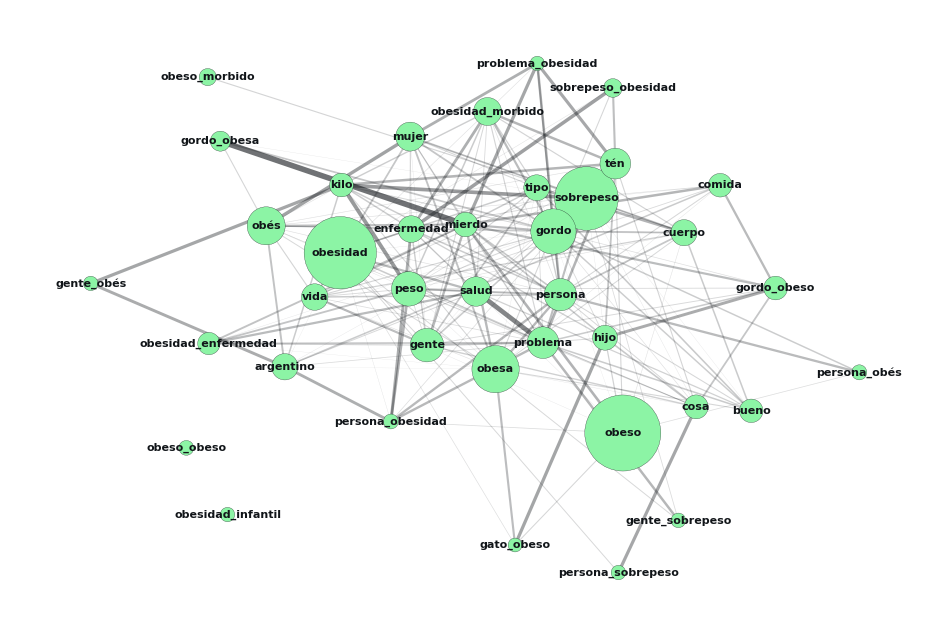

In [114]:
generate_graph_plt(nodes_df, links_df, config)

### Análisis estadístico

#### Ejercicio 6

Se comenzará el plan de análisis que será desarrollado a lo largo de los tres prácticos. En esta primera parte más introductoria les propongo:

* a. Reconocer posibles correlaciones entre variables. ¿En qué supuesto se basan?. Luego de aplicar el test estadístico interpretar los resultados y fundamentar la elección del mismo a partir de la naturaleza de los datos. No duden en consultarme ante cualquier inconveniente en este punto!

In [ ]:
df.conversationId.value_counts()

In [ ]:
df[['cantidad_palabras','retweetCount']].describe()

In [ ]:
df[['cantidad_palabras','retweetCount']].hist(bins=30)

Dado que retweetCount suele estar muy sesgada (muchos ceros y pocos valores altos) y cantidad_palabras también puede no ser normal, Spearman es más apropiado: no exige normalidad ni homocedasticidad y captura relaciones monotónicas.

Usamos Spearman porque no exige normalidad, es robusto a outliers y porque la relación entre número de palabras y retweets suele ser monotónica (a más palabras “útiles”, más probabilidades de retuiteo), pero no estrictamente lineal.

Presentamos también Pearson para comparar y confirmar que ambas métricas apuntan a correlaciones positivas débiles.

In [ ]:
from scipy.stats import pearsonr, spearmanr

x = df['cantidad_palabras']
y = df['retweetCount']

# Pearson
r_p, p_p = pearsonr(x, y)
print(f"Pearson r = {r_p:.3f}, p-value = {p_p:.3e}")

# Spearman
r_s, p_s = spearmanr(x, y)
print(f"Spearman ρ = {r_s:.3f}, p-value = {p_s:.3e}")

Significancia estadística

Ambos p-values son extremadamente bajos (p ≪ 0.001), por lo que puedes rechazar con total confianza la hipótesis nula de “no correlación”. Esto es esperable cuando tienes un tamaño de muestra muy grande (n = 11 111): incluso correlaciones muy pequeñas salen “significativas”.

Tamaño del efecto (coeficientes de correlación)

Pearson r = 0.093
Esto te dice que solo un 0.093 de covariación lineal estándar hay entre cantidad_palabras y retweetCount. En términos de varianza explicada, r² ≈ 0.0087 → menos de un 1 % de la variabilidad en retweets se explica linealmente por la longitud del texto.

Spearman ρ = 0.116
Al basarse en rangos, ρ capta cualquier relación monotónica. Aquí ρ ≈ 0.12 sigue siendo pequeño, pero ligeramente mayor que Pearson, lo que sugiere que hay una relación monotónica débil (no estrictamente lineal): a más palabras, tiende a haber algo más de retweets, pero poco.

Interpretación práctica

Aunque ambos tests dan “significancia estadística”, el tamaño del efecto es muy pequeño. En la práctica, la longitud del mensaje no es un buen predictor de cuántos retweets va a tener.

Debes distinguir entre “significancia” (p-value) y “fuerza de la asociación” (r o ρ). Aquí la fuerza es débil, así que sería riesgoso usar la cantidad de palabras como criterio único para estimar retweets.

Recomendaciones

Podrías explorar transformaciones (por ejemplo log(retweetCount+1)) o añadir otras variables (contenido, hashtags, hora de publicación) para mejorar la explicación de la variabilidad.

Visualiza con un diagrama de dispersión (scatter plot) y, si quieres, la línea de tendencia, para ver cómo se distribuyen los puntos y corroborar que no hay un patrón fuerte.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, pearsonr, spearmanr, kendalltau
import warnings
warnings.filterwarnings('ignore')

# Si quieres analizar múltiples correlaciones:
def analisis_multiple_correlaciones(df, variables_numericas):
    """
    Análisis de correlaciones múltiples
    """
    print("MATRIZ DE CORRELACIONES")
    print("="*50)

    # Matriz de correlación de Pearson
    print("\nMatriz de Pearson:")
    corr_pearson = df[variables_numericas].corr(method='pearson')
    print(corr_pearson.round(3))

    # Matriz de correlación de Spearman
    print("\nMatriz de Spearman:")
    corr_spearman = df[variables_numericas].corr(method='spearman')
    print(corr_spearman.round(3))

    # Heatmap
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f')
    plt.title('Correlaciones de Pearson')

    plt.subplot(1, 2, 2)
    sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f')
    plt.title('Correlaciones de Spearman')

    plt.tight_layout()
    plt.show()

# EJEMPLO PARA TU DATASET:
variables_interes = ['replyCount', 'retweetCount', 'likeCount', 'quoteCount',
                     'longitud_mensaje', 'cantidad_palabras']
analisis_multiple_correlaciones(df, variables_interes)

In [ ]:
# Supongamos que tu DataFrame se llama 'df'
# df = pd.read_csv('tu_archivo.csv')  # Cargar tus datos aquí

def analizar_correlacion(df, var1, var2):
    """
    Función para analizar correlación entre dos variables
    """
    print("="*60)
    print(f"ANÁLISIS DE CORRELACIÓN: {var1} vs {var2}")
    print("="*60)

    # 1. ESTADÍSTICAS DESCRIPTIVAS
    print("\n1. ESTADÍSTICAS DESCRIPTIVAS")
    print("-"*30)
    print(f"{var1}:")
    print(f"  Media: {df[var1].mean():.2f}")
    print(f"  Mediana: {df[var1].median():.2f}")
    print(f"  Desv. Std: {df[var1].std():.2f}")
    print(f"  Min-Max: {df[var1].min()} - {df[var1].max()}")

    print(f"\n{var2}:")
    print(f"  Media: {df[var2].mean():.2f}")
    print(f"  Mediana: {df[var2].median():.2f}")
    print(f"  Desv. Std: {df[var2].std():.2f}")
    print(f"  Min-Max: {df[var2].min()} - {df[var2].max()}")

    # 2. VERIFICACIÓN DE NORMALIDAD
    print("\n2. TESTS DE NORMALIDAD")
    print("-"*30)

    # Test de Shapiro-Wilk (muestra aleatoria si n > 5000)
    if len(df) > 5000:
        sample_df = df.sample(n=5000, random_state=42)
        print("(Análisis en muestra aleatoria de 5000 observaciones)")
    else:
        sample_df = df

    # Normalidad para var1
    shapiro_stat1, shapiro_p1 = shapiro(sample_df[var1])
    print(f"\n{var1} - Test de Shapiro-Wilk:")
    print(f"  Estadístico: {shapiro_stat1:.4f}")
    print(f"  p-valor: {shapiro_p1:.6f}")
    print(f"  {'Normal' if shapiro_p1 > 0.05 else 'No normal'} (α = 0.05)")

    # Normalidad para var2
    shapiro_stat2, shapiro_p2 = shapiro(sample_df[var2])
    print(f"\n{var2} - Test de Shapiro-Wilk:")
    print(f"  Estadístico: {shapiro_stat2:.4f}")
    print(f"  p-valor: {shapiro_p2:.6f}")
    print(f"  {'Normal' if shapiro_p2 > 0.05 else 'No normal'} (α = 0.05)")

    # 3. DETECCIÓN DE OUTLIERS
    print("\n3. DETECCIÓN DE OUTLIERS (Método IQR)")
    print("-"*30)

    def detectar_outliers(serie, nombre):
        Q1 = serie.quantile(0.25)
        Q3 = serie.quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        outliers = serie[(serie < limite_inf) | (serie > limite_sup)]
        print(f"{nombre}:")
        print(f"  Límites: [{limite_inf:.2f}, {limite_sup:.2f}]")
        print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(serie)*100:.1f}%)")
        return outliers

    outliers1 = detectar_outliers(df[var1], var1)
    outliers2 = detectar_outliers(df[var2], var2)

    # 4. CÁLCULO DE CORRELACIONES
    print("\n4. COEFICIENTES DE CORRELACIÓN")
    print("-"*30)

    # Pearson
    pearson_r, pearson_p = pearsonr(df[var1], df[var2])
    print(f"Correlación de Pearson:")
    print(f"  r = {pearson_r:.4f}")
    print(f"  p-valor = {pearson_p:.6f}")
    print(f"  {'Significativa' if pearson_p < 0.05 else 'No significativa'} (α = 0.05)")

    # Spearman
    spearman_rho, spearman_p = spearmanr(df[var1], df[var2])
    print(f"\nCorrelación de Spearman:")
    print(f"  ρ = {spearman_rho:.4f}")
    print(f"  p-valor = {spearman_p:.6f}")
    print(f"  {'Significativa' if spearman_p < 0.05 else 'No significativa'} (α = 0.05)")

    # Kendall
    kendall_tau, kendall_p = kendalltau(df[var1], df[var2])
    print(f"\nCorrelación de Kendall:")
    print(f"  τ = {kendall_tau:.4f}")
    print(f"  p-valor = {kendall_p:.6f}")
    print(f"  {'Significativa' if kendall_p < 0.05 else 'No significativa'} (α = 0.05)")

    # 5. RECOMENDACIÓN
    print("\n5. RECOMENDACIÓN DE TEST")
    print("-"*30)

    normal1 = shapiro_p1 > 0.05
    normal2 = shapiro_p2 > 0.05
    outliers_muchos = (len(outliers1) + len(outliers2)) / (2 * len(df)) > 0.05

    if normal1 and normal2 and not outliers_muchos:
        recomendacion = "Pearson"
        justificacion = "Ambas variables siguen distribución normal y hay pocos outliers"
    elif outliers_muchos:
        recomendacion = "Kendall"
        justificacion = "Presencia significativa de outliers (Kendall es más robusto)"
    else:
        recomendacion = "Spearman"
        justificacion = "Al menos una variable no sigue distribución normal"

    print(f"Test recomendado: {recomendacion}")
    print(f"Justificación: {justificacion}")

    # 6. VISUALIZACIÓN
    print("\n6. GENERANDO GRÁFICOS...")
    print("-"*30)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Scatter plot
    axes[0,0].scatter(df[var1], df[var2], alpha=0.5)
    axes[0,0].set_xlabel(var1)
    axes[0,0].set_ylabel(var2)
    axes[0,0].set_title(f'Scatter Plot: {var1} vs {var2}')

    # Histogramas
    axes[0,1].hist(df[var1], bins=50, alpha=0.7, color='blue')
    axes[0,1].set_xlabel(var1)
    axes[0,1].set_ylabel('Frecuencia')
    axes[0,1].set_title(f'Distribución de {var1}')

    axes[1,0].hist(df[var2], bins=50, alpha=0.7, color='red')
    axes[1,0].set_xlabel(var2)
    axes[1,0].set_ylabel('Frecuencia')
    axes[1,0].set_title(f'Distribución de {var2}')

    # Boxplots
    axes[1,1].boxplot([df[var1], df[var2]], labels=[var1, var2])
    axes[1,1].set_title('Boxplots para detección de outliers')

    plt.tight_layout()
    plt.show()

    return {
        'pearson': (pearson_r, pearson_p),
        'spearman': (spearman_rho, spearman_p),
        'kendall': (kendall_tau, kendall_p),
        'recomendacion': recomendacion
    }

# EJEMPLO DE USO:
# Asumiendo que tienes tu DataFrame cargado como 'df'
resultados = analizar_correlacion(df, 'cantidad_palabras', 'retweetCount')

In [ ]:
df.info()

- Correlación entre el mes y las provincias? No creo si la mayoría de tweets son de una sola, está muy desbalanceada esa categoría.
- Correlación entre métricas de interacción, es probable que sí, los tweets virales suelen tener muchas métricas con valores altos.
- Correlación de las métricas de interacción con algún hashtag en particular, **creo que esta opción tiene más sentido**.
- Correlación entre alguna métrica de interacción y el user_id o conversationId, **esta también me parece interesante**.
- Correlación entre la cantidad de palabras y alguna métrica de interacción.
- Correlación entre la cantidad de palabras y los hashtags.

### Ejercicio final

* ¿Qué hallazgos te parecieron más interesantes?
* ¿Qué hipótesis o líneas de análisis podrías plantear a partir de lo visto?
* A partir del ejercicio 5. ¿Qué otras variables o aspectos sería útil incorporar en el análisis?


La fecha de entrega del práctico es para el día 30/6, la semana del 16/6 tendremos una instancia de consulta con cada grupo para ver como vienen con el práctico. El entregable será una notebook, vayan realizando visualizaciones pensando en la presentación de video posterior al segundo práctico.
Recuerden que es una instancia de aprendizaje por lo cual no duden en consultar lo que necesiten para resolver el práctico.  

Les dejo disponibles algunos recursos de introducción al NLP y text mining que podrían ser de utilidad.

NLP avanzado con spacy: https://course.spacy.io/es/